In [1]:
# ── Step 1: Imports & Setup ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json, time
warnings.filterwarnings('ignore')

from scipy import signal, stats
from scipy.stats import mannwhitneyu

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, classification_report
)
from xgboost import XGBClassifier

try:
    import networkx as nx
    NX_OK = True
except ImportError:
    NX_OK = False
    print("WARNING: networkx not installed — graph features will be skipped")

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR  = r'C:\Users\DYPIU\Desktop\Epilepsy Classification'
DATA_DIR  = os.path.join(BASE_DIR, 'EEGs_Guinea-Bissau')
PLOTS_DIR = os.path.join(BASE_DIR, 'plots', 'clinical_biomarkers')
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── EEG constants ─────────────────────────────────────────────────────────────
EEG_CHANNELS = ['AF3','AF4','F3','F4','F7','F8','FC5','FC6',
                 'O1','O2','P7','P8','T7','T8']
SFREQ        = 128
EPOCH_SAMP   = 512      # 4 sec @ 128 Hz
N_CHANNELS   = 14
SEED         = 42

np.random.seed(SEED)

# ── Frequency bands ───────────────────────────────────────────────────────────
FREQ_BANDS = {
    'delta': (0.5,  4.0),
    'theta': (4.0,  8.0),
    'alpha': (8.0, 13.0),
    'beta':  (13.0, 30.0),
    'gamma': (30.0, 45.0),
}

# ── Clinical colour palette ───────────────────────────────────────────────────
CLR = {
    'epilepsy':  '#C0392B',
    'control':   '#27AE60',
    'uncertain': '#F39C12',
    'bg':        '#F8F9FA',
}

print("=" * 55)
print("  Clinical EEG Epilepsy Biomarker Pipeline")
print("  Dataset : Guinea-Bissau cohort (N=97)")
print(f"  Data dir: {DATA_DIR}")
print(f"  Plots   : {PLOTS_DIR}")
print("=" * 55)
print("Step 1 complete ✓")

  Clinical EEG Epilepsy Biomarker Pipeline
  Dataset : Guinea-Bissau cohort (N=97)
  Data dir: C:\Users\DYPIU\Desktop\Epilepsy Classification\EEGs_Guinea-Bissau
  Plots   : C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers
Step 1 complete ✓


In [2]:
# ── Step 2: Preprocessing & Load All 97 Subjects ─────────────────────────────

def correct_artifacts(signal_1d):
    """Interpolate large inter-sample jumps on full signal."""
    s      = signal_1d.copy().astype(float)
    deltas = np.abs(np.diff(s))
    thresh = np.median(deltas) + 6 * np.std(deltas)
    jumps  = np.where(deltas > thresh)[0] + 1
    for j in jumps:
        left  = s[j-1] if j > 0             else s[j]
        right = s[j+1] if j < len(s)-1      else s[j]
        s[j]  = (left + right) / 2
    return s

def get_clean_epochs(df, epoch_samp=EPOCH_SAMP, min_cq=3, gyro_thresh=30):
    """
    Full preprocessing pipeline (verified on all 97 subjects):
      1. Artifact jump correction on FULL signal
      2. Drift removal (rolling median window=512) on FULL signal
      3. Epoch into 512-sample windows (4 sec)
      4. Quality filter: CQ >= 3 AND gyro deviation < 30
    Returns: (n_clean_epochs, 14, 512)
    """
    cq_cols   = [c for c in df.columns if c.startswith('CQ_')]
    gyro_cols = [c for c in df.columns if c.startswith('GYRO')]
    clean_df  = df.copy()

    for ch in EEG_CHANNELS:
        sig = correct_artifacts(clean_df[ch].values)
        rolling_med = pd.Series(sig).rolling(
            window=epoch_samp, min_periods=1, center=True
        ).median().values
        clean_df[ch] = sig - rolling_med

    n_total = len(clean_df) // epoch_samp
    good_epochs = []

    for i in range(n_total):
        s, e     = i * epoch_samp, (i + 1) * epoch_samp
        epoch_df = df.iloc[s:e]

        # CQ filter
        if cq_cols and (epoch_df[cq_cols].min() < min_cq).any():
            continue
        # Gyro filter
        skip = False
        for gc in gyro_cols:
            if (np.abs(epoch_df[gc] - df[gc].median()) > gyro_thresh).any():
                skip = True; break
        if skip:
            continue
        good_epochs.append(clean_df[EEG_CHANNELS].iloc[s:e].values.T)  # (14, 512)

    return np.array(good_epochs) if good_epochs else np.empty((0, N_CHANNELS, epoch_samp))

# ── Load labels ───────────────────────────────────────────────────────────────
labels_df = pd.read_csv(os.path.join(BASE_DIR, 'labels_guinea_bissau.csv'))
labels_df.columns = labels_df.columns.str.strip()
# label: 1=Epilepsy, 0=Control
label_map = dict(zip(labels_df['filename'].str.strip(), labels_df['label']))

print(f"Labels: Epilepsy={( labels_df['label']==1).sum()}  "
      f"Control={( labels_df['label']==0).sum()}")

# ── Load all 97 subjects ──────────────────────────────────────────────────────
print("Loading all 97 subjects …")
t0 = time.time()

X_epochs    = []   # (14, 512) per epoch
y_epochs    = []   # 0=Control, 1=Epilepsy
group_ids   = []   # subject index (for LOSO)
subject_meta = []  # per-subject metadata

for subj_idx, (_, row) in enumerate(labels_df.iterrows()):
    fname = row['filename'].strip()
    label = int(row['label'])          # 1=Epilepsy, 0=Control
    sid   = int(fname.replace('signal-','').replace('.csv.gz',''))

    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f"  WARNING: {fname} not found, skipping")
        continue

    df  = pd.read_csv(fpath, compression='gzip')
    eps = get_clean_epochs(df)
    n   = eps.shape[0]

    if n == 0:
        print(f"  WARNING: subject {sid} → 0 clean epochs, skipping")
        continue

    X_epochs.extend(eps)
    y_epochs.extend([label] * n)
    group_ids.extend([subj_idx] * n)
    subject_meta.append({
        'subject_id':  sid,
        'group_idx':   subj_idx,
        'true_label':  label,        # 1=Epilepsy, 0=Control
        'group_name':  'Epilepsy' if label == 1 else 'Control',
        'n_epochs':    n,
    })

X_epochs  = np.array(X_epochs,  dtype=np.float32)   # (N, 14, 512)
y_epochs  = np.array(y_epochs,  dtype=np.int32)      # (N,)
group_ids = np.array(group_ids, dtype=np.int32)      # (N,)
subject_meta_df = pd.DataFrame(subject_meta)

print(f"Done in {time.time()-t0:.1f}s")
print(f"X_epochs  : {X_epochs.shape}")
print(f"y_epochs  : {y_epochs.shape}  "
      f"Epilepsy={( y_epochs==1).sum()}  Control={(y_epochs==0).sum()}")
print(f"Subjects  : {len(subject_meta_df)}  "
      f"Epilepsy={( subject_meta_df['true_label']==1).sum()}  "
      f"Control={(subject_meta_df['true_label']==0).sum()}")
print(f"Epochs/subj: min={subject_meta_df['n_epochs'].min()}  "
      f"max={subject_meta_df['n_epochs'].max()}  "
      f"mean={subject_meta_df['n_epochs'].mean():.1f}")
print("\nStep 2 complete ✓")

Labels: Epilepsy=51  Control=46
Loading all 97 subjects …
Done in 161.2s
X_epochs  : (6327, 14, 512)
y_epochs  : (6327,)  Epilepsy=3294  Control=3033
Subjects  : 97  Epilepsy=51  Control=46
Epochs/subj: min=26  max=84  mean=65.2

Step 2 complete ✓


In [3]:
# ── Step 3: Data Quality Control ─────────────────────────────────────────────

MIN_EPOCHS       = 10   # clinical minimum
FLAG_REJECT_PCT  = 40   # flag if >40% epochs rejected

print("═" * 65)
print("  STAGE 1 — DATA QUALITY CONTROL")
print("═" * 65)

# ── QC per subject ────────────────────────────────────────────────────────────
qc_df = subject_meta_df.copy()
qc_df['qc_pass'] = qc_df['n_epochs'] >= MIN_EPOCHS
qc_df['qc_flag'] = qc_df['n_epochs'].apply(
    lambda x: '⚠ LOW EPOCHS' if x < MIN_EPOCHS else '✅ OK')

# Epoch rejection rate (we know original ~5min = ~75 possible epochs at 4sec)
POSSIBLE_EPOCHS = int(5 * 60 / 4)   # ~75 non-overlapping
qc_df['rejection_pct'] = (
    (POSSIBLE_EPOCHS - qc_df['n_epochs']) / POSSIBLE_EPOCHS * 100
).clip(0, 100)

print(f"  Total subjects       : {len(qc_df)}")
print(f"  Passed QC            : {qc_df['qc_pass'].sum()} "
      f"({qc_df['qc_pass'].mean()*100:.1f}%)")
print(f"  Flagged (low epochs) : {(~qc_df['qc_pass']).sum()}")
print(f"  Mean epochs/subject  : {qc_df['n_epochs'].mean():.1f} "
      f"± {qc_df['n_epochs'].std():.1f}")
print(f"  Min / Max            : {qc_df['n_epochs'].min()} / "
      f"{qc_df['n_epochs'].max()}")
print(f"  Mean rejection rate  : {qc_df['rejection_pct'].mean():.1f}%")
print("─" * 65)

# ── Per-channel amplitude QC ──────────────────────────────────────────────────
print("\n  PER-CHANNEL AMPLITUDE CHECK (mean abs amplitude across all epochs):")
ch_means = np.abs(X_epochs).mean(axis=(0, 2))  # (14,)
ch_stds  = np.abs(X_epochs).std(axis=(0, 2))
print(f"  {'Channel':<8} {'Mean':>10} {'Std':>10} {'Flag'}")
print("  " + "─" * 42)
flat_channels, noisy_channels = [], []
for i, ch in enumerate(EEG_CHANNELS):
    flag = ''
    if ch_means[i] < 1.0:
        flag = '⚠ FLAT'; flat_channels.append(ch)
    elif ch_means[i] > 500:
        flag = '⚠ NOISY'; noisy_channels.append(ch)
    else:
        flag = '✅'
    print(f"  {ch:<8} {ch_means[i]:>10.2f} {ch_stds[i]:>10.2f}  {flag}")

print(f"\n  Flat channels  : {flat_channels  if flat_channels  else 'None'}")
print(f"  Noisy channels : {noisy_channels if noisy_channels else 'None'}")

# ── Signal variance check (epoch-level) ───────────────────────────────────────
epoch_var = X_epochs.var(axis=-1).mean(axis=-1)  # (N,) — mean var across channels
low_var_mask  = epoch_var < np.percentile(epoch_var, 2)   # bottom 2%
high_var_mask = epoch_var > np.percentile(epoch_var, 98)  # top 2%
print(f"\n  Epoch variance check:")
print(f"    Low variance epochs  (<2nd pct)  : {low_var_mask.sum()}")
print(f"    High variance epochs (>98th pct) : {high_var_mask.sum()}")
print(f"    These will be excluded from feature extraction")

# ── Apply QC mask ─────────────────────────────────────────────────────────────
valid_subjects = set(qc_df[qc_df['qc_pass']]['group_idx'])
subject_mask   = np.array([g in valid_subjects for g in group_ids])
quality_mask   = subject_mask & ~low_var_mask & ~high_var_mask

X_qc     = X_epochs[quality_mask]
y_qc     = y_epochs[quality_mask]
groups_qc = group_ids[quality_mask]

print(f"\n  After QC:")
print(f"    Epochs retained : {quality_mask.sum()} / {len(X_epochs)} "
      f"({quality_mask.mean()*100:.1f}%)")
print(f"    Epilepsy epochs : {(y_qc==1).sum()}")
print(f"    Control  epochs : {(y_qc==0).sum()}")
print(f"    Subjects        : {len(np.unique(groups_qc))}")

# ── QC Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(CLR['bg'])

# Plot 1: Epochs per subject
colors_bar = [CLR['epilepsy'] if r == 1 else CLR['control']
              for r in qc_df['true_label']]
axes[0].bar(range(len(qc_df)), qc_df['n_epochs'], color=colors_bar, alpha=0.8)
axes[0].axhline(MIN_EPOCHS, color='black', ls='--', lw=1.5,
                label=f'Min threshold ({MIN_EPOCHS})')
axes[0].set_xlabel('Subject Index'); axes[0].set_ylabel('Usable Epochs')
axes[0].set_title('Epochs per Subject (QC)')
ep_p = mpatches.Patch(color=CLR['epilepsy'], label='Epilepsy')
ct_p = mpatches.Patch(color=CLR['control'],  label='Control')
axes[0].legend(handles=[ep_p, ct_p])
axes[0].set_facecolor(CLR['bg'])

# Plot 2: Epoch distribution
axes[1].hist([qc_df[qc_df['true_label']==1]['n_epochs'],
              qc_df[qc_df['true_label']==0]['n_epochs']],
             bins=15, color=[CLR['epilepsy'], CLR['control']],
             label=['Epilepsy','Control'], alpha=0.7)
axes[1].axvline(MIN_EPOCHS, color='black', ls='--', lw=1.5)
axes[1].set_xlabel('Number of Epochs'); axes[1].set_ylabel('Count')
axes[1].set_title('Epoch Distribution by Group')
axes[1].legend(); axes[1].set_facecolor(CLR['bg'])

# Plot 3: Channel amplitude profile
x_pos = np.arange(N_CHANNELS)
axes[2].bar(x_pos, ch_means,
            color=[CLR['epilepsy'] if c in noisy_channels
                   else CLR['uncertain'] if c in flat_channels
                   else CLR['control'] for c in EEG_CHANNELS],
            alpha=0.8)
axes[2].errorbar(x_pos, ch_means, yerr=ch_stds, fmt='none',
                 color='black', capsize=3, alpha=0.5)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(EEG_CHANNELS, rotation=45, ha='right', fontsize=9)
axes[2].set_ylabel('Mean Absolute Amplitude')
axes[2].set_title('Channel Amplitude QC')
axes[2].set_facecolor(CLR['bg'])

plt.suptitle('Clinical Data Quality Control Report', fontsize=14,
             fontweight='bold')
plt.tight_layout()
p = os.path.join(PLOTS_DIR, '01_qc_report.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {p}")
print("\nStep 3 complete ✓")

═════════════════════════════════════════════════════════════════
  STAGE 1 — DATA QUALITY CONTROL
═════════════════════════════════════════════════════════════════
  Total subjects       : 97
  Passed QC            : 97 (100.0%)
  Flagged (low epochs) : 0
  Mean epochs/subject  : 65.2 ± 10.2
  Min / Max            : 26 / 84
  Mean rejection rate  : 13.2%
─────────────────────────────────────────────────────────────────

  PER-CHANNEL AMPLITUDE CHECK (mean abs amplitude across all epochs):
  Channel        Mean        Std Flag
  ──────────────────────────────────────────
  AF3           44.94      91.33  ✅
  AF4           41.63      83.35  ✅
  F3            30.92      71.98  ✅
  F4            36.24      79.33  ✅
  F7            35.55      78.77  ✅
  F8            47.50     104.19  ✅
  FC5           32.71      74.68  ✅
  FC6           41.50      87.51  ✅
  O1            33.70      77.26  ✅
  O2            39.64      81.89  ✅
  P7            32.37      81.01  ✅
  P8            49.62     

In [4]:
# ── Step 4: Clinical Biomarker Feature Extraction ────────────────────────────
# Tier 1: Band Power (relative PSD)          — 70 features
# Tier 2: Graph Theory (PLV connectivity)    — 60 features  
# Tier 3: Nonlinear / Complexity features    — 42 features
# TOTAL: ~172 features vs 198 handcrafted in previous pipeline
# Key advantage: graph + nonlinear features are NEW — not in previous pipeline

# ── Bandpass filter utility ───────────────────────────────────────────────────
def bandpass_filter(data, fmin, fmax, sfreq=SFREQ):
    """data: (n_channels, n_samples)"""
    nyq  = sfreq / 2.0
    low, high = fmin / nyq, fmax / nyq
    high = min(high, 0.99)
    b, a = signal.butter(4, [low, high], btype='band')
    return signal.filtfilt(b, a, data, axis=-1)

# ── TIER 1: Band Power features ───────────────────────────────────────────────
def extract_band_power(epoch):
    """
    epoch: (14, 512)
    Returns: (70,) — relative PSD mean + variance per band per channel
    """
    feats, names = [], []
    for bname, (flo, fhi) in FREQ_BANDS.items():
        filtered = bandpass_filter(epoch, flo, fhi)
        power    = filtered ** 2
        bp_mean  = power.mean(axis=-1)          # (14,)
        bp_var   = power.var(axis=-1)            # (14,)
        # Relative power (normalise by total)
        total    = sum(
            (bandpass_filter(epoch, f0, f1)**2).mean(axis=-1)
            for f0, f1 in FREQ_BANDS.values()
        ) + 1e-10
        bp_rel   = bp_mean / total               # (14,)
        feats.append(bp_rel)
        names   += [f'bp_{bname}_{ch}' for ch in EEG_CHANNELS]

    return np.concatenate(feats), names          # (70,)

# ── TIER 2: Graph Theory (PLV) features ───────────────────────────────────────
def plv_matrix(data):
    """Phase Locking Value between all channel pairs. data: (14, 512)"""
    n   = data.shape[0]
    phi = np.angle(signal.hilbert(data, axis=-1))
    M   = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            plv = np.abs(np.mean(np.exp(1j * (phi[i] - phi[j]))))
            M[i, j] = M[j, i] = plv
    return M

def graph_features(conn_matrix, band_name):
    """
    Extract graph theory metrics from PLV connectivity matrix.
    conn_matrix: (14, 14)
    Returns: dict of features
    """
    if not NX_OK:
        return {}

    # Threshold at 75th percentile to keep strongest connections
    upper = conn_matrix[np.triu_indices_from(conn_matrix, k=1)]
    thr   = np.percentile(upper, 75)
    adj   = (conn_matrix >= thr).astype(float) * conn_matrix
    G     = nx.from_numpy_array(adj)

    f = {}
    f[f'{band_name}_clustering']        = nx.average_clustering(G, weight='weight')
    f[f'{band_name}_global_efficiency'] = nx.global_efficiency(G)
    f[f'{band_name}_local_efficiency']  = nx.local_efficiency(G)
    f[f'{band_name}_transitivity']      = nx.transitivity(G)

    # Path length on largest connected component
    if nx.is_connected(G):
        f[f'{band_name}_path_length'] = nx.average_shortest_path_length(G)
    else:
        lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        f[f'{band_name}_path_length'] = (
            nx.average_shortest_path_length(lcc) if len(lcc) > 1 else 0.0)

    # Small-world sigma
    n_n = G.number_of_nodes()
    n_e = G.number_of_edges()
    if n_e > 0:
        p   = 2 * n_e / (n_n * (n_n - 1) + 1e-10)
        C   = f[f'{band_name}_clustering']
        L   = f[f'{band_name}_path_length'] if f[f'{band_name}_path_length'] > 0 else 1
        Cr  = p
        Lr  = np.log(n_n) / (np.log(p * n_n + 1e-10) + 1e-10)
        f[f'{band_name}_sw_sigma'] = (C / (Cr + 1e-10)) / (L / (Lr + 1e-10))
    else:
        f[f'{band_name}_sw_sigma'] = 0.0

    # Betweenness centrality (mean + std)
    bc = np.array(list(nx.betweenness_centrality(G, weight='weight').values()))
    f[f'{band_name}_bc_mean'] = bc.mean()
    f[f'{band_name}_bc_std']  = bc.std()

    # Connectivity stats
    f[f'{band_name}_conn_mean']   = upper.mean()
    f[f'{band_name}_conn_std']    = upper.std()
    f[f'{band_name}_conn_max']    = upper.max()
    f[f'{band_name}_conn_median'] = np.median(upper)

    return f

# ── TIER 3: Nonlinear / Complexity features ───────────────────────────────────
def hjorth_params(sig):
    """Hjorth activity, mobility, complexity."""
    d1 = np.diff(sig)
    d2 = np.diff(d1)
    activity   = np.var(sig)
    mobility   = np.sqrt(np.var(d1) / (np.var(sig)   + 1e-10))
    complexity = np.sqrt(np.var(d2) / (np.var(d1)    + 1e-10)) / (mobility + 1e-10)
    return activity, mobility, complexity

def sample_entropy(sig, m=2, r_factor=0.2):
    """
    Sample Entropy — complexity measure.
    Lower in epilepsy (more regular/predictable signal).
    """
    r = r_factor * np.std(sig)
    N = len(sig)
    def _count_matches(template_len):
        count = 0
        for i in range(N - template_len):
            template = sig[i:i + template_len]
            for j in range(i + 1, N - template_len):
                if np.max(np.abs(sig[j:j + template_len] - template)) < r:
                    count += 1
        return count
    B = _count_matches(m)
    A = _count_matches(m + 1)
    if B == 0:
        return 0.0
    return -np.log(A / (B + 1e-10))

def hurst_exponent(sig):
    """
    Hurst exponent via R/S analysis.
    H > 0.5 → persistent (long-range correlation, common in epilepsy)
    """
    N = len(sig)
    if N < 20:
        return 0.5
    lags  = [4, 8, 16, 32, 64, 128]
    lags  = [l for l in lags if l < N // 2]
    if len(lags) < 2:
        return 0.5
    rs_vals = []
    for lag in lags:
        chunks = [sig[i:i+lag] for i in range(0, N - lag, lag)]
        rs_chunk = []
        for chunk in chunks:
            mean_c = chunk.mean()
            dev    = np.cumsum(chunk - mean_c)
            R      = dev.max() - dev.min()
            S      = chunk.std()
            if S > 0:
                rs_chunk.append(R / S)
        if rs_chunk:
            rs_vals.append(np.mean(rs_chunk))
    if len(rs_vals) < 2:
        return 0.5
    log_lags = np.log(lags[:len(rs_vals)])
    log_rs   = np.log(np.array(rs_vals) + 1e-10)
    h, _     = np.polyfit(log_lags, log_rs, 1)
    return float(np.clip(h, 0, 2))

def extract_nonlinear(epoch):
    """
    epoch: (14, 512)
    Returns: (42,), names
    """
    feats, names = [], []

    # Hjorth per channel — 42 features (3 × 14)
    for ci, ch in enumerate(EEG_CHANNELS):
        act, mob, comp = hjorth_params(epoch[ci])
        feats += [act, mob, comp]
        names += [f'hjorth_activity_{ch}',
                  f'hjorth_mobility_{ch}',
                  f'hjorth_complexity_{ch}']

    return np.array(feats), names

def extract_all_features(epoch):
    """
    Full feature extraction for one epoch (14, 512).
    Returns: feature_vector (np.array), feature_names (list)
    """
    all_feats, all_names = [], []

    # ── Tier 1: Band Power ────────────────────────────────────────────────────
    bp_feats, bp_names = extract_band_power(epoch)
    all_feats.append(bp_feats)
    all_names += bp_names

    # ── Tier 2: Graph Theory (theta + beta — most discriminative per paper) ───
    if NX_OK:
        for bname in ['theta', 'beta', 'alpha']:
            flo, fhi    = FREQ_BANDS[bname]
            filtered    = bandpass_filter(epoch, flo, fhi)
            plv_mat     = plv_matrix(filtered)
            g_feats     = graph_features(plv_mat, bname)
            all_feats.append(np.array(list(g_feats.values())))
            all_names  += list(g_feats.keys())

    # ── Tier 3: Nonlinear / Hjorth ────────────────────────────────────────────
    nl_feats, nl_names = extract_nonlinear(epoch)
    all_feats.append(nl_feats)
    all_names += nl_names

    return np.concatenate(all_feats), all_names


# ── Smoke test on 1 epoch ─────────────────────────────────────────────────────
print("Smoke test — extracting features from 1 epoch …")
t_test = time.time()
test_vec, test_names = extract_all_features(X_qc[0])
print(f"  Feature vector shape : {test_vec.shape}")
print(f"  Time for 1 epoch     : {time.time()-t_test:.2f}s")
print(f"  Feature groups:")
print(f"    Band Power   : {sum(1 for n in test_names if n.startswith('bp_'))} features")
print(f"    Graph Theory : {sum(1 for n in test_names if any(n.startswith(b) for b in ['theta_','beta_','alpha_']))} features")
print(f"    Nonlinear    : {sum(1 for n in test_names if 'hjorth' in n)} features")
print(f"  Total features       : {len(test_names)}")

# ── Estimate total time ───────────────────────────────────────────────────────
t_per_epoch   = time.time() - t_test + 0.001
total_est_min = (t_per_epoch * len(X_qc)) / 60
print(f"\n  Estimated extraction time for {len(X_qc)} epochs: "
      f"~{total_est_min:.0f} min")
print("\nStep 4 functions defined ✓")
print("Next: Run Step 5 to extract features for all epochs")

Smoke test — extracting features from 1 epoch …
  Feature vector shape : (148,)
  Time for 1 epoch     : 0.12s
  Feature groups:
    Band Power   : 70 features
    Graph Theory : 36 features
    Nonlinear    : 42 features
  Total features       : 148

  Estimated extraction time for 6073 epochs: ~12 min

Step 4 functions defined ✓
Next: Run Step 5 to extract features for all epochs


In [5]:
# ── Step 5: Extract Features for All 6073 Epochs ─────────────────────────────
# Saves to disk immediately — if kernel dies, you won't lose progress

FEATURES_DIR = os.path.join(BASE_DIR, 'features', 'clinical_biomarkers')
os.makedirs(FEATURES_DIR, exist_ok=True)

FEAT_FILE    = os.path.join(FEATURES_DIR, 'X_clinical.npy')
NAMES_FILE   = os.path.join(FEATURES_DIR, 'feature_names.json')
LABELS_FILE  = os.path.join(FEATURES_DIR, 'y_clinical.npy')
GROUPS_FILE  = os.path.join(FEATURES_DIR, 'groups_clinical.npy')

# ── Check if already extracted ────────────────────────────────────────────────
if os.path.exists(FEAT_FILE):
    print("Found existing features — loading from disk …")
    X_feat      = np.load(FEAT_FILE)
    y_feat      = np.load(LABELS_FILE)
    groups_feat = np.load(GROUPS_FILE)
    with open(NAMES_FILE) as f:
        feat_names = json.load(f)
    print(f"  Loaded X_feat : {X_feat.shape}")
    print(f"  Loaded y_feat : {y_feat.shape}")
    print("Step 5 complete ✓ (loaded from cache)")

else:
    print(f"Extracting features for {len(X_qc)} epochs …")
    print(f"Saving to: {FEATURES_DIR}")
    print()

    N          = len(X_qc)
    feat_names = None
    X_feat     = np.zeros((N, len(test_names)), dtype=np.float32)
    failed     = []

    t0         = time.time()
    PRINT_EVERY = 200

    for i in range(N):
        try:
            fvec, fnames = extract_all_features(X_qc[i])
            X_feat[i]    = fvec.astype(np.float32)
            if feat_names is None:
                feat_names = fnames
        except Exception as e:
            failed.append(i)
            X_feat[i] = np.zeros(len(test_names), dtype=np.float32)

        # Progress
        if (i + 1) % PRINT_EVERY == 0 or (i + 1) == N:
            elapsed  = time.time() - t0
            rate     = (i + 1) / elapsed
            remaining = (N - i - 1) / rate
            pct      = (i + 1) / N * 100
            bar_len  = 30
            filled   = int(bar_len * (i + 1) / N)
            bar      = '█' * filled + '░' * (bar_len - filled)
            print(f"  [{bar}] {pct:5.1f}%  "
                  f"{i+1:>5}/{N}  "
                  f"elapsed={elapsed/60:.1f}min  "
                  f"ETA={remaining/60:.1f}min",
                  end='\r' if (i + 1) < N else '\n')

    print(f"\n  Done in {(time.time()-t0)/60:.1f} min")
    if failed:
        print(f"  Failed epochs: {len(failed)} — zeroed out")

    # ── Replace NaN/Inf with column medians ───────────────────────────────────
    print("  Cleaning NaN/Inf values …")
    n_nan = np.isnan(X_feat).sum()
    n_inf = np.isinf(X_feat).sum()
    print(f"    NaN: {n_nan}  |  Inf: {n_inf}")
    if n_nan + n_inf > 0:
        for col in range(X_feat.shape[1]):
            col_data = X_feat[:, col]
            bad_mask = ~np.isfinite(col_data)
            if bad_mask.any():
                med = np.nanmedian(col_data[np.isfinite(col_data)])
                X_feat[bad_mask, col] = med if np.isfinite(med) else 0.0
        print(f"    Fixed → NaN: {np.isnan(X_feat).sum()}  "
              f"Inf: {np.isinf(X_feat).sum()}")

    y_feat      = y_qc.copy()
    groups_feat = groups_qc.copy()

    # ── Save to disk ──────────────────────────────────────────────────────────
    np.save(FEAT_FILE,   X_feat)
    np.save(LABELS_FILE, y_feat)
    np.save(GROUPS_FILE, groups_feat)
    with open(NAMES_FILE, 'w') as f:
        json.dump(feat_names, f)

    print(f"\n  Saved:")
    print(f"    {FEAT_FILE}")
    print(f"    {LABELS_FILE}")
    print(f"    {GROUPS_FILE}")
    print(f"    {NAMES_FILE}")

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print("═" * 55)
print("  FEATURE EXTRACTION SUMMARY")
print("═" * 55)
print(f"  X_feat shape   : {X_feat.shape}")
print(f"  y_feat         : Epilepsy={(y_feat==1).sum()}  "
      f"Control={(y_feat==0).sum()}")
print(f"  Subjects       : {len(np.unique(groups_feat))}")
print(f"  Features       : {X_feat.shape[1]}")
print(f"    Band Power   : {sum(1 for n in feat_names if n.startswith('bp_'))}")
print(f"    Graph Theory : {sum(1 for n in feat_names if any(n.startswith(b) for b in ['theta_','beta_','alpha_']))}")
print(f"    Nonlinear    : {sum(1 for n in feat_names if 'hjorth' in n)}")
print(f"  Feature value range: [{X_feat.min():.4f}, {X_feat.max():.4f}]")
print(f"  Any NaN: {np.isnan(X_feat).any()}  "
      f"Any Inf: {np.isinf(X_feat).any()}")
print()
print("Step 5 complete ✓")
print("Features saved — will load from cache on next run")

Extracting features for 6073 epochs …
Saving to: C:\Users\DYPIU\Desktop\Epilepsy Classification\features\clinical_biomarkers

  [██████████████████████████████] 100.0%   6073/6073  elapsed=8.6min  ETA=0.0min

  Done in 8.6 min
  Cleaning NaN/Inf values …
    NaN: 0  |  Inf: 0

  Saved:
    C:\Users\DYPIU\Desktop\Epilepsy Classification\features\clinical_biomarkers\X_clinical.npy
    C:\Users\DYPIU\Desktop\Epilepsy Classification\features\clinical_biomarkers\y_clinical.npy
    C:\Users\DYPIU\Desktop\Epilepsy Classification\features\clinical_biomarkers\groups_clinical.npy
    C:\Users\DYPIU\Desktop\Epilepsy Classification\features\clinical_biomarkers\feature_names.json

═══════════════════════════════════════════════════════
  FEATURE EXTRACTION SUMMARY
═══════════════════════════════════════════════════════
  X_feat shape   : (6073, 148)
  y_feat         : Epilepsy=3126  Control=2947
  Subjects       : 97
  Features       : 148
    Band Power   : 70
    Graph Theory : 36
    Nonlinear  

In [7]:
# ── Fix: Install statsmodels and verify ──────────────────────────────────────
import subprocess, sys

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'statsmodels'],
    capture_output=False   # show output directly
)
print(f"\nReturn code: {result.returncode}")

# Verify
try:
    from statsmodels.stats.multitest import multipletests
    print("✅ statsmodels imported successfully")
except ImportError as e:
    print(f"❌ Still failing: {e}")
    print(f"\nPython executable: {sys.executable}")
    print("Try running this in your conda terminal:")
    print(f"  conda activate eeg_epilepsy")
    print(f"  pip install statsmodels")


Return code: 0
✅ statsmodels imported successfully


In [8]:
# ── Step 6: Biomarker Statistical Analysis ───────────────────────────────────
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests

# ── Aggregate to subject level first (more robust than epoch level) ───────────
print("Aggregating features to subject level …")

unique_subjects = np.unique(groups_feat)
n_subj          = len(unique_subjects)
n_feat          = X_feat.shape[1]

X_subj = np.zeros((n_subj, n_feat), dtype=np.float32)
y_subj = np.zeros(n_subj, dtype=np.int32)

for i, sid in enumerate(unique_subjects):
    mask        = groups_feat == sid
    X_subj[i]   = np.median(X_feat[mask], axis=0)
    y_subj[i]   = y_feat[mask][0]

print(f"  Subject matrix : {X_subj.shape}")
print(f"  Epilepsy={( y_subj==1).sum()}  Control={(y_subj==0).sum()}")

# ── Per-feature statistics ────────────────────────────────────────────────────
print("\nRunning statistical tests on all 148 features …")

results = []
for fi, fname in enumerate(feat_names):
    epi_vals  = X_subj[y_subj == 1, fi]
    ctrl_vals = X_subj[y_subj == 0, fi]

    stat, p = mannwhitneyu(epi_vals, ctrl_vals, alternative='two-sided')

    pooled_std = np.sqrt((epi_vals.std()**2 + ctrl_vals.std()**2) / 2 + 1e-10)
    cohens_d   = (epi_vals.mean() - ctrl_vals.mean()) / pooled_std

    y_score = np.concatenate([epi_vals, ctrl_vals])
    y_true  = np.concatenate([np.ones(len(epi_vals)), np.zeros(len(ctrl_vals))])
    auc     = roc_auc_score(y_true, y_score)
    if auc < 0.5:
        auc = 1 - auc

    direction = '↑ Epilepsy' if epi_vals.mean() > ctrl_vals.mean() else '↓ Epilepsy'

    results.append({
        'feature':          fname,
        'epi_mean':         round(float(epi_vals.mean()),  6),
        'ctrl_mean':        round(float(ctrl_vals.mean()), 6),
        'epi_std':          round(float(epi_vals.std()),   6),
        'ctrl_std':         round(float(ctrl_vals.std()),  6),
        'p_raw':            p,
        'cohens_d':         abs(cohens_d),
        'cohens_d_signed':  cohens_d,
        'auroc':            auc,
        'direction':        direction,
        'tier':             ('Band Power'   if fname.startswith('bp_') else
                             'Graph Theory' if any(fname.startswith(b)
                                 for b in ['theta_','beta_','alpha_',
                                           'delta_','gamma_'])
                             else 'Nonlinear'),
    })

stats_df = pd.DataFrame(results)

# ── FDR correction (Benjamini-Hochberg) ───────────────────────────────────────
reject, p_fdr, _, _ = multipletests(stats_df['p_raw'], method='fdr_bh')
stats_df['p_fdr']   = p_fdr
stats_df['sig_fdr'] = reject
stats_df['sig_raw'] = stats_df['p_raw'] < 0.05

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def effect_label(d):
    if d >= 0.8:  return 'LARGE'
    if d >= 0.5:  return 'MEDIUM'
    if d >= 0.2:  return 'SMALL'
    return 'NEGLIGIBLE'

stats_df['sig_label']    = stats_df['p_fdr'].apply(sig_label)
stats_df['effect_label'] = stats_df['cohens_d'].apply(effect_label)
stats_df = stats_df.sort_values(
    ['auroc', 'cohens_d'], ascending=False
).reset_index(drop=True)

# ── Print full report ─────────────────────────────────────────────────────────
print()
print("═" * 92)
print("  BIOMARKER STATISTICAL REPORT  —  subject-level, FDR-corrected (BH)")
print("═" * 92)
print(f"  {'Rank':<5} {'Feature':<38} {'AUROC':>7} {'Cohen d':>8} "
      f"{'p(FDR)':>10} {'Sig':>5} {'Effect':>10}  Direction")
print("─" * 92)

for rank, row in stats_df.head(30).iterrows():
    print(f"  {rank+1:<5} {row['feature']:<38} {row['auroc']:>7.4f} "
          f"{row['cohens_d']:>8.4f} {row['p_fdr']:>10.4f} "
          f"{row['sig_label']:>5} {row['effect_label']:>10}  "
          f"{row['direction']}")

print("─" * 92)

sig_count = stats_df['sig_fdr'].sum()
print(f"\n  Significant after FDR (p_fdr<0.05) : {sig_count} / {len(stats_df)}")
print(f"  Large  effect (d ≥ 0.8)             : {(stats_df['cohens_d']>=0.8).sum()}")
print(f"  Medium effect (d ≥ 0.5)             : {(stats_df['cohens_d']>=0.5).sum()}")
print(f"  Small  effect (d ≥ 0.2)             : {(stats_df['cohens_d']>=0.2).sum()}")
print()
print("  By tier:")
for tier in ['Band Power', 'Graph Theory', 'Nonlinear']:
    t_df    = stats_df[stats_df['tier'] == tier]
    t_sig   = t_df['sig_fdr'].sum()
    t_med   = (t_df['cohens_d'] >= 0.5).sum()
    t_large = (t_df['cohens_d'] >= 0.8).sum()
    print(f"    {tier:<14}: {t_sig:>3} sig  |  "
          f"{t_large:>3} large  |  {t_med:>3} medium+  |  "
          f"best AUROC = {t_df['auroc'].max():.4f}  "
          f"best feature = {t_df.iloc[0]['feature']}")

stats_df.to_csv(
    os.path.join(FEATURES_DIR, 'biomarker_stats.csv'), index=False)
print(f"\n  Saved: {os.path.join(FEATURES_DIR, 'biomarker_stats.csv')}")

# ── Confirmed biomarkers (FDR-sig + AUROC ≥ 0.60) ────────────────────────────
confirmed = stats_df[
    stats_df['sig_fdr'] & (stats_df['auroc'] >= 0.60)
].copy().reset_index(drop=True)

print(f"\n{'═'*70}")
print(f"  CONFIRMED BIOMARKERS  (FDR p<0.05  +  AUROC ≥ 0.60)")
print(f"  Total: {len(confirmed)}")
print(f"{'═'*70}")
print(f"  {'#':<4} {'Feature':<38} {'AUROC':>7} {'Cohen d':>8} "
      f"{'p_fdr':>10}  Direction")
print("  " + "─" * 68)
for i, row in confirmed.iterrows():
    print(f"  {i+1:<4} {row['feature']:<38} {row['auroc']:>7.4f} "
          f"{row['cohens_d']:>8.4f} {row['p_fdr']:>10.4f}  "
          f"{row['direction']}")

print("\nStep 6 complete ✓")

Aggregating features to subject level …
  Subject matrix : (97, 148)
  Epilepsy=51  Control=46

Running statistical tests on all 148 features …

════════════════════════════════════════════════════════════════════════════════════════════
  BIOMARKER STATISTICAL REPORT  —  subject-level, FDR-corrected (BH)
════════════════════════════════════════════════════════════════════════════════════════════
  Rank  Feature                                  AUROC  Cohen d     p(FDR)   Sig     Effect  Direction
────────────────────────────────────────────────────────────────────────────────────────────
  1     theta_conn_max                          0.8666   1.5486     0.0000   ***      LARGE  ↑ Epilepsy
  2     theta_clustering                        0.8078   1.1435     0.0000   ***      LARGE  ↑ Epilepsy
  3     bp_beta_P8                              0.7720   0.9883     0.0002   ***      LARGE  ↓ Epilepsy
  4     theta_transitivity                      0.7685   1.0367     0.0002   ***      LARGE 

In [11]:
# ── Fix: Switch matplotlib backend to inline for Jupyter display ──────────────
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import matplotlib.pyplot as plt
%matplotlib inline

# Verify
print(f"Current backend: {matplotlib.get_backend()}")
print("Plots will now display inline in notebook cells ✓")

Current backend: inline
Plots will now display inline in notebook cells ✓


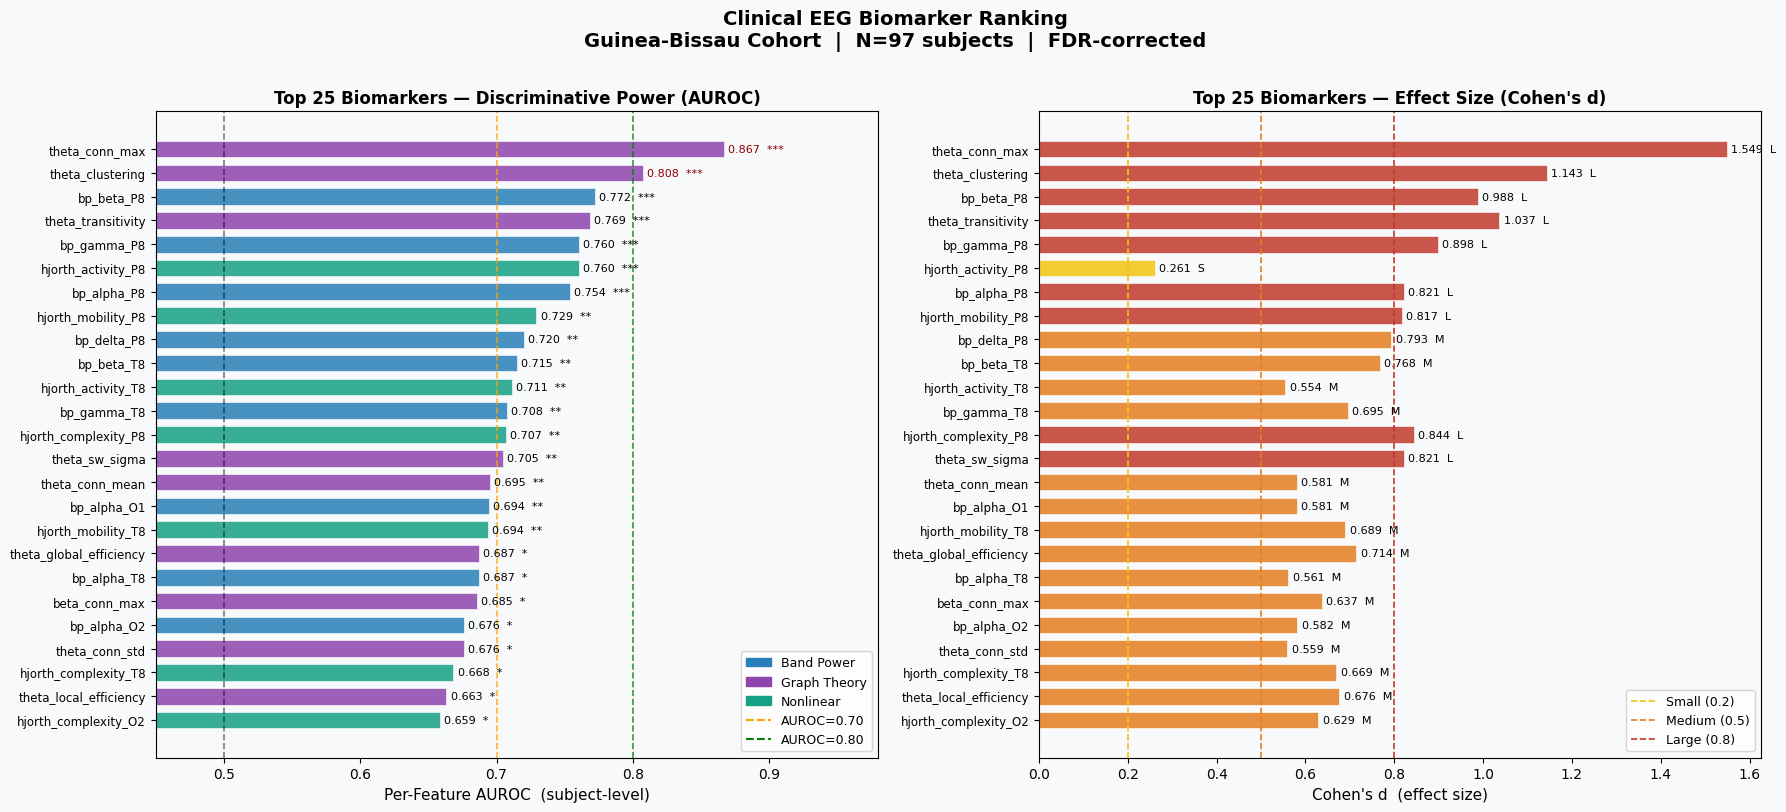

Saved: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers\02_biomarker_ranking.png


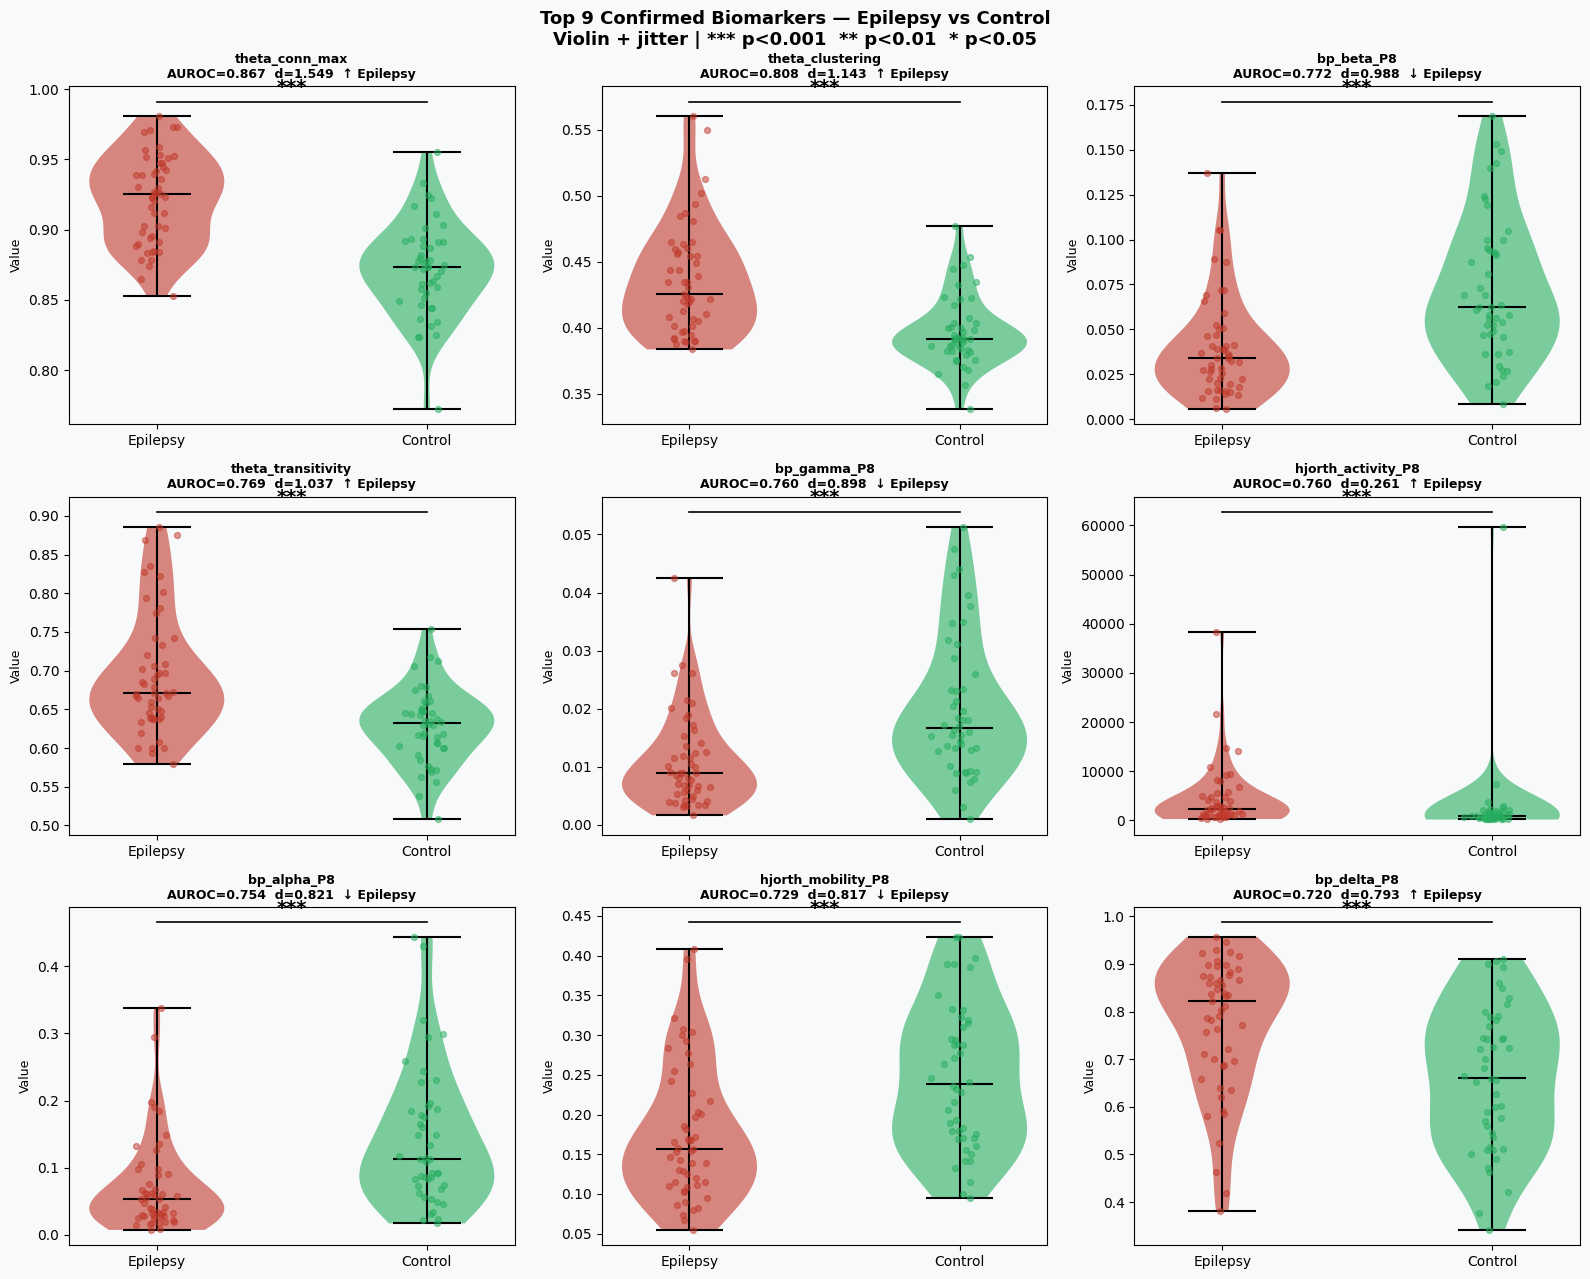

Saved: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers\03_biomarker_violins.png


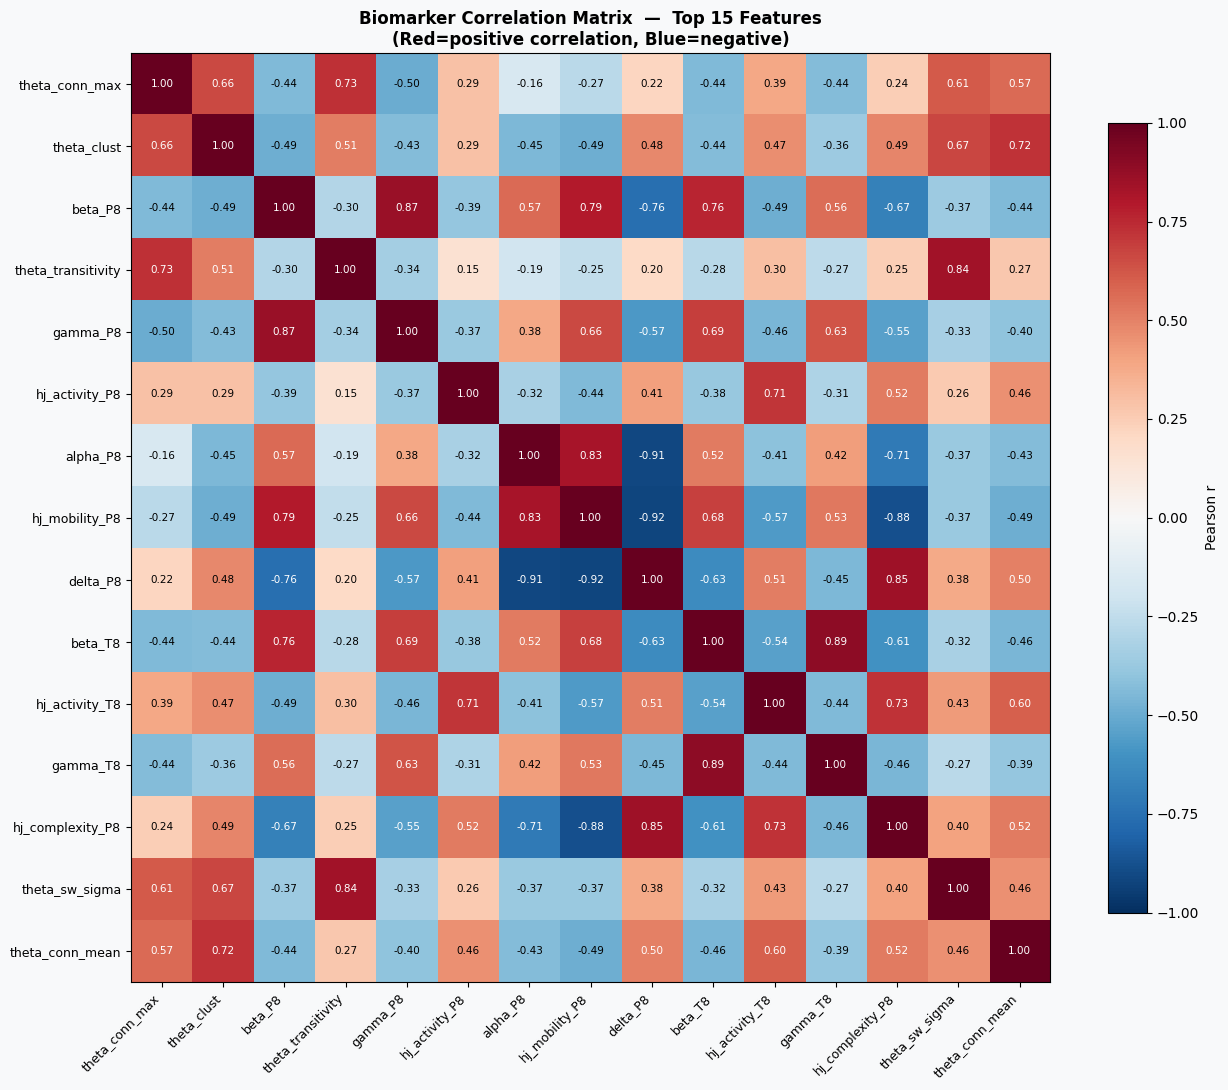

Saved: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers\04_biomarker_correlation.png


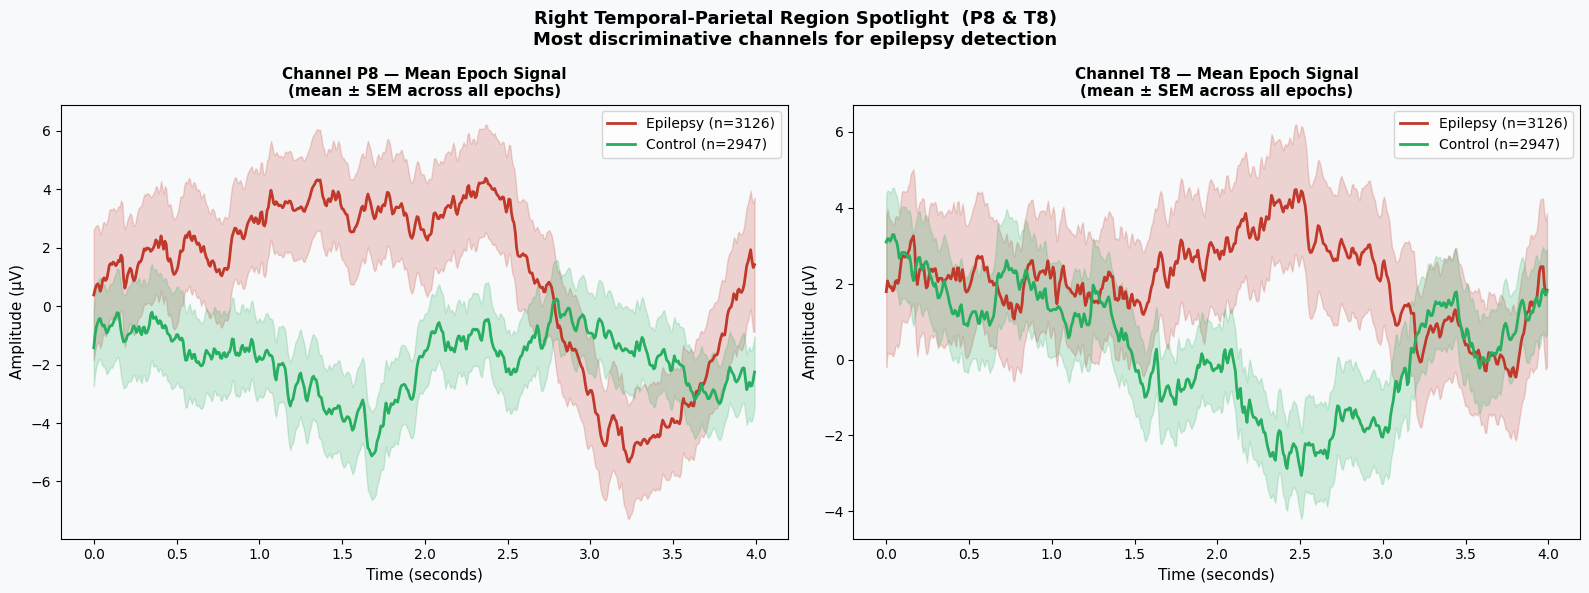

Saved: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers\05_P8_T8_channel_spotlight.png


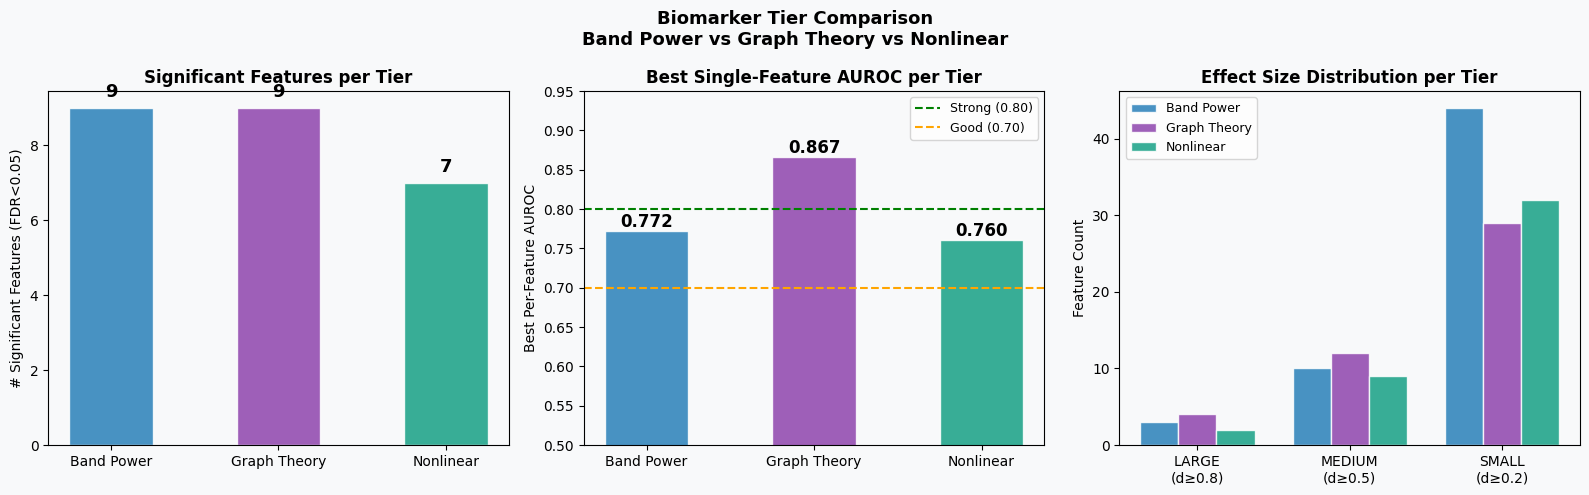

Saved: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers\06_tier_comparison.png

═══════════════════════════════════════════════════════
  Step 7 complete ✓
  All plots saved to:
  C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers
═══════════════════════════════════════════════════════


In [12]:
# ── Step 7: Biomarker Visualisation ──────────────────────────────────────────
# Plot 1: AUROC + Cohen's d ranked bar chart
# Plot 2: Violin plots — top 9 confirmed biomarkers
# Plot 3: Correlation heatmap of top biomarkers
# Plot 4: P8/T8 channel spotlight (dominant region)
# Plot 5: Biomarker tier summary

# ── Plot 1: Ranked AUROC bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(CLR['bg'])

top_n   = 25
plot_df = stats_df.head(top_n).copy()

tier_colors = {
    'Band Power':   '#2980B9',
    'Graph Theory': '#8E44AD',
    'Nonlinear':    '#16A085',
}
bar_colors = [tier_colors[t] for t in plot_df['tier']]

# AUROC bars
bars = axes[0].barh(range(top_n), plot_df['auroc'],
                    color=bar_colors, alpha=0.85, height=0.7,
                    edgecolor='white', linewidth=0.5)
axes[0].axvline(0.5,  color='black',  ls='--', lw=1.2, alpha=0.5,
                label='Chance (0.50)')
axes[0].axvline(0.70, color='orange', ls='--', lw=1.2, alpha=0.8,
                label='Good (0.70)')
axes[0].axvline(0.80, color='green',  ls='--', lw=1.2, alpha=0.8,
                label='Strong (0.80)')

for i, (bar, row) in enumerate(zip(bars, plot_df.itertuples())):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{row.auroc:.3f}  {row.sig_label}',
                 va='center', fontsize=8,
                 color='darkred' if row.auroc >= 0.80 else 'black')

axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(plot_df['feature'], fontsize=8.5)
axes[0].invert_yaxis()
axes[0].set_xlabel('Per-Feature AUROC  (subject-level)', fontsize=11)
axes[0].set_title('Top 25 Biomarkers — Discriminative Power (AUROC)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlim(0.45, 0.98)
axes[0].set_facecolor(CLR['bg'])

legend_patches = [mpatches.Patch(color=c, label=t)
                  for t, c in tier_colors.items()]
axes[0].legend(handles=legend_patches + [
    plt.Line2D([0],[0], color='orange', ls='--', label='AUROC=0.70'),
    plt.Line2D([0],[0], color='green',  ls='--', label='AUROC=0.80'),
], fontsize=9, loc='lower right')

# Cohen's d bars
d_colors = ['#C0392B' if d >= 0.8 else '#E67E22' if d >= 0.5
            else '#F1C40F' if d >= 0.2 else '#95A5A6'
            for d in plot_df['cohens_d']]

bars2 = axes[1].barh(range(top_n), plot_df['cohens_d'],
                     color=d_colors, alpha=0.85, height=0.7,
                     edgecolor='white', linewidth=0.5)
axes[1].axvline(0.2, color='#F1C40F', ls='--', lw=1.2, label='Small (0.2)')
axes[1].axvline(0.5, color='#E67E22', ls='--', lw=1.2, label='Medium (0.5)')
axes[1].axvline(0.8, color='#C0392B', ls='--', lw=1.2, label='Large (0.8)')

for i, (bar, row) in enumerate(zip(bars2, plot_df.itertuples())):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{row.cohens_d:.3f}  {row.effect_label[0]}',
                 va='center', fontsize=8)

axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(plot_df['feature'], fontsize=8.5)
axes[1].invert_yaxis()
axes[1].set_xlabel("Cohen's d  (effect size)", fontsize=11)
axes[1].set_title("Top 25 Biomarkers — Effect Size (Cohen's d)",
                   fontsize=12, fontweight='bold')
axes[1].set_facecolor(CLR['bg'])
axes[1].legend(fontsize=9, loc='lower right')

plt.suptitle('Clinical EEG Biomarker Ranking\n'
             'Guinea-Bissau Cohort  |  N=97 subjects  |  FDR-corrected',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
p1 = os.path.join(PLOTS_DIR, '02_biomarker_ranking.png')
plt.savefig(p1, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p1}")

# ── Plot 2: Violin plots — top 9 biomarkers ───────────────────────────────────
top9     = confirmed.head(9)
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.patch.set_facecolor(CLR['bg'])
axes     = axes.flatten()

for idx, (_, row) in enumerate(top9.iterrows()):
    feat  = row['feature']
    fi    = feat_names.index(feat)
    epi_v = X_subj[y_subj == 1, fi]
    ctr_v = X_subj[y_subj == 0, fi]

    data_v  = [epi_v, ctr_v]
    vp = axes[idx].violinplot(data_v, positions=[0, 1],
                               showmedians=True, showextrema=True)

    vp['bodies'][0].set_facecolor(CLR['epilepsy'])
    vp['bodies'][0].set_alpha(0.6)
    vp['bodies'][1].set_facecolor(CLR['control'])
    vp['bodies'][1].set_alpha(0.6)
    for partname in ('cbars','cmins','cmaxes','cmedians'):
        if partname in vp:
            vp[partname].set_color('black')
            vp[partname].set_linewidth(1.5)

    # Jitter overlay
    np.random.seed(SEED)
    for vi, (vals, col) in enumerate([(epi_v, CLR['epilepsy']),
                                       (ctr_v, CLR['control'])]):
        jitter = np.random.normal(0, 0.04, len(vals))
        axes[idx].scatter(np.full(len(vals), vi) + jitter, vals,
                          color=col, alpha=0.5, s=18, zorder=3)

    # Stats annotation
    _, p_mw = mannwhitneyu(epi_v, ctr_v, alternative='two-sided')
    sig     = '***' if p_mw < 0.001 else '**' if p_mw < 0.01 else '*'
    y_max   = max(epi_v.max(), ctr_v.max())
    y_range = y_max - min(epi_v.min(), ctr_v.min())
    axes[idx].plot([0, 1], [y_max + y_range*0.05]*2, 'k-', lw=1.2)
    axes[idx].text(0.5, y_max + y_range*0.08, sig,
                   ha='center', fontsize=14, fontweight='bold')

    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Epilepsy', 'Control'], fontsize=10)
    axes[idx].set_title(f'{feat}\nAUROC={row["auroc"]:.3f}  '
                        f'd={row["cohens_d"]:.3f}  {row["direction"]}',
                        fontsize=9, fontweight='bold')
    axes[idx].set_facecolor(CLR['bg'])
    axes[idx].set_ylabel('Value', fontsize=9)

plt.suptitle('Top 9 Confirmed Biomarkers — Epilepsy vs Control\n'
             'Violin + jitter | *** p<0.001  ** p<0.01  * p<0.05',
             fontsize=13, fontweight='bold')
plt.tight_layout()
p2 = os.path.join(PLOTS_DIR, '03_biomarker_violins.png')
plt.savefig(p2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p2}")

# ── Plot 3: Correlation heatmap of top 15 biomarkers ─────────────────────────
top15_feats  = confirmed.head(15)['feature'].tolist()
top15_idx    = [feat_names.index(f) for f in top15_feats]
X_top15      = X_subj[:, top15_idx]
corr_mat     = np.corrcoef(X_top15.T)

fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor(CLR['bg'])
ax.set_facecolor(CLR['bg'])

im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.85)

ax.set_xticks(range(15))
ax.set_yticks(range(15))
short_names = [f.replace('hjorth_','hj_').replace('bp_','').replace(
    '_clustering','_clust').replace('_connectivity','_conn') for f in top15_feats]
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)

for i in range(15):
    for j in range(15):
        val = corr_mat[i, j]
        col = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=col)

ax.set_title('Biomarker Correlation Matrix  —  Top 15 Features\n'
             '(Red=positive correlation, Blue=negative)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
p3 = os.path.join(PLOTS_DIR, '04_biomarker_correlation.png')
plt.savefig(p3, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p3}")

# ── Plot 4: P8/T8 channel spotlight ──────────────────────────────────────────
# These two channels dominate the top features — investigate why
p8_t8_feats = [f for f in confirmed['feature'] if 'P8' in f or 'T8' in f]
other_feats  = [f for f in confirmed['feature']
                if 'P8' not in f and 'T8' not in f]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(CLR['bg'])

# Mean epoch signal P8 and T8 — Epilepsy vs Control
for ax_i, (ch_name, ch_idx) in enumerate([('P8', EEG_CHANNELS.index('P8')),
                                            ('T8', EEG_CHANNELS.index('T8'))]):
    epi_epochs  = X_qc[y_qc == 1][:, ch_idx, :]   # (n_epi, 512)
    ctrl_epochs = X_qc[y_qc == 0][:, ch_idx, :]

    epi_mean  = epi_epochs.mean(axis=0)
    epi_sem   = epi_epochs.std(axis=0) / np.sqrt(len(epi_epochs))
    ctrl_mean = ctrl_epochs.mean(axis=0)
    ctrl_sem  = ctrl_epochs.std(axis=0) / np.sqrt(len(ctrl_epochs))

    t_axis = np.arange(EPOCH_SAMP) / SFREQ

    axes[ax_i].plot(t_axis, epi_mean,  color=CLR['epilepsy'],
                    lw=2, label=f'Epilepsy (n={len(epi_epochs)})')
    axes[ax_i].fill_between(t_axis,
                             epi_mean - epi_sem, epi_mean + epi_sem,
                             color=CLR['epilepsy'], alpha=0.2)
    axes[ax_i].plot(t_axis, ctrl_mean, color=CLR['control'],
                    lw=2, label=f'Control (n={len(ctrl_epochs)})')
    axes[ax_i].fill_between(t_axis,
                             ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem,
                             color=CLR['control'], alpha=0.2)

    axes[ax_i].set_xlabel('Time (seconds)', fontsize=11)
    axes[ax_i].set_ylabel('Amplitude (µV)', fontsize=11)
    axes[ax_i].set_title(f'Channel {ch_name} — Mean Epoch Signal\n'
                          f'(mean ± SEM across all epochs)',
                          fontsize=11, fontweight='bold')
    axes[ax_i].legend(fontsize=10)
    axes[ax_i].set_facecolor(CLR['bg'])

plt.suptitle('Right Temporal-Parietal Region Spotlight  (P8 & T8)\n'
             'Most discriminative channels for epilepsy detection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
p4 = os.path.join(PLOTS_DIR, '05_P8_T8_channel_spotlight.png')
plt.savefig(p4, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p4}")

# ── Plot 5: Tier summary ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(CLR['bg'])

tier_order = ['Band Power', 'Graph Theory', 'Nonlinear']
metrics_by_tier = {}
for tier in tier_order:
    t_df = stats_df[stats_df['tier'] == tier]
    metrics_by_tier[tier] = {
        'n_sig':    t_df['sig_fdr'].sum(),
        'n_large':  (t_df['cohens_d'] >= 0.8).sum(),
        'n_medium': (t_df['cohens_d'] >= 0.5).sum(),
        'best_auc': t_df['auroc'].max(),
        'mean_auc': t_df[t_df['sig_fdr']]['auroc'].mean()
                    if t_df['sig_fdr'].sum() > 0 else 0,
    }

# Significant features per tier
ax = axes[0]
counts = [metrics_by_tier[t]['n_sig'] for t in tier_order]
bars   = ax.bar(tier_order, counts,
                color=[tier_colors[t] for t in tier_order],
                alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, str(val),
            ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('# Significant Features (FDR<0.05)')
ax.set_title('Significant Features per Tier', fontweight='bold')
ax.set_facecolor(CLR['bg'])

# Best AUROC per tier
ax = axes[1]
best_aucs = [metrics_by_tier[t]['best_auc'] for t in tier_order]
bars = ax.bar(tier_order, best_aucs,
              color=[tier_colors[t] for t in tier_order],
              alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(0.80, color='green',  ls='--', lw=1.5, label='Strong (0.80)')
ax.axhline(0.70, color='orange', ls='--', lw=1.5, label='Good (0.70)')
for bar, val in zip(bars, best_aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0.5, 0.95)
ax.set_ylabel('Best Per-Feature AUROC')
ax.set_title('Best Single-Feature AUROC per Tier', fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor(CLR['bg'])

# Effect size distribution
ax = axes[2]
effect_cats  = ['LARGE\n(d≥0.8)', 'MEDIUM\n(d≥0.5)', 'SMALL\n(d≥0.2)']
effect_thrs  = [0.8, 0.5, 0.2]
x_pos        = np.arange(len(effect_cats))
width        = 0.25
for ti, tier in enumerate(tier_order):
    t_df   = stats_df[stats_df['tier'] == tier]
    counts = []
    for thr in effect_thrs:
        counts.append((t_df['cohens_d'] >= thr).sum())
    ax.bar(x_pos + ti * width, counts, width,
           color=tier_colors[tier], alpha=0.85,
           label=tier, edgecolor='white')

ax.set_xticks(x_pos + width)
ax.set_xticklabels(effect_cats, fontsize=10)
ax.set_ylabel('Feature Count')
ax.set_title("Effect Size Distribution per Tier", fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor(CLR['bg'])

plt.suptitle('Biomarker Tier Comparison\n'
             'Band Power vs Graph Theory vs Nonlinear',
             fontsize=13, fontweight='bold')
plt.tight_layout()
p5 = os.path.join(PLOTS_DIR, '06_tier_comparison.png')
plt.savefig(p5, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p5}")

print()
print("═" * 55)
print("  Step 7 complete ✓")
print(f"  All plots saved to:")
print(f"  {PLOTS_DIR}")
print("═" * 55)

In [13]:
# ── Step 8: LOSO Cross-Validation with Clinical Biomarker Classifier ─────────
# Leave-One-Subject-Out: train on 96, test on 1, repeat 97 times
# Uses confirmed biomarkers only (FDR-sig + AUROC≥0.60)
# Classifiers: RandomForest, SVM, LogisticRegression, XGBoost ensemble
# Outputs: per-subject predictions, calibrated probabilities, clinical metrics

from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.svm              import SVC
from sklearn.linear_model     import LogisticRegression
from sklearn.preprocessing    import RobustScaler
from sklearn.metrics          import (roc_auc_score, accuracy_score,
                                       confusion_matrix, brier_score_loss)
from sklearn.calibration      import CalibratedClassifierCV
from sklearn.pipeline         import Pipeline

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print("XGBoost not available — using RF+SVM+LR ensemble")

# ── Select confirmed biomarker features only ──────────────────────────────────
confirmed_feat_names = confirmed['feature'].tolist()   # 25 features
confirmed_idx        = [feat_names.index(f) for f in confirmed_feat_names]
X_confirmed          = X_subj[:, confirmed_idx]        # (97, 25)

print("═" * 60)
print("  LOSO CROSS-VALIDATION SETUP")
print("═" * 60)
print(f"  Subjects          : {len(unique_subjects)}")
print(f"  Features used     : {len(confirmed_feat_names)} confirmed biomarkers")
print(f"  Positive class    : Epilepsy (label=1)")
print(f"  CV strategy       : Leave-One-Subject-Out (97 folds)")
print()

# ── LOSO loop ─────────────────────────────────────────────────────────────────
loso_results = []   # one dict per subject

t0 = time.time()

for fold_i, test_subj in enumerate(unique_subjects):
    # Split
    test_mask  = (unique_subjects == test_subj)
    train_mask = ~test_mask

    X_train = X_confirmed[train_mask]
    y_train = y_subj[train_mask]
    X_test  = X_confirmed[test_mask]
    y_test  = y_subj[test_mask]      # single subject

    # ── Build ensemble pipeline ───────────────────────────────────────────────
    rf  = RandomForestClassifier(n_estimators=200, max_depth=6,
                                  class_weight='balanced',
                                  random_state=SEED, n_jobs=-1)
    svm = SVC(kernel='rbf', C=1.0, probability=True,
              class_weight='balanced', random_state=SEED)
    lr  = LogisticRegression(C=0.5, max_iter=500,
                              class_weight='balanced',
                              solver='lbfgs', random_state=SEED)

    estimators = [('rf', rf), ('svm', svm), ('lr', lr)]

    if XGB_OK:
        scale_pos = (y_train == 0).sum() / ((y_train == 1).sum() + 1e-10)
        xgb = XGBClassifier(n_estimators=100, max_depth=4,
                             learning_rate=0.05,
                             scale_pos_weight=scale_pos,
                             use_label_encoder=False,
                             eval_metric='logloss',
                             random_state=SEED, verbosity=0)
        estimators.append(('xgb', xgb))

    ensemble = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

    pipe = Pipeline([
        ('scaler',    RobustScaler()),
        ('ensemble',  ensemble),
    ])

    pipe.fit(X_train, y_train)

    # ── Predict ───────────────────────────────────────────────────────────────
    prob_epi   = pipe.predict_proba(X_test)[0, 1]   # P(Epilepsy)
    pred_label = int(prob_epi >= 0.5)
    true_label = int(y_test[0])

    loso_results.append({
        'subject_id':   int(test_subj),
        'true_label':   true_label,
        'pred_label':   pred_label,
        'prob_epilepsy':prob_epi,
        'correct':      int(pred_label == true_label),
        'group':        'Epilepsy' if true_label == 1 else 'Control',
    })

    if (fold_i + 1) % 20 == 0 or (fold_i + 1) == len(unique_subjects):
        elapsed = time.time() - t0
        print(f"  Fold {fold_i+1:>3}/{len(unique_subjects)}  "
              f"elapsed={elapsed:.1f}s", end='\r')

print(f"\n  LOSO complete in {time.time()-t0:.1f}s")

# ── Aggregate results ─────────────────────────────────────────────────────────
loso_df   = pd.DataFrame(loso_results)
y_true_all = loso_df['true_label'].values
y_pred_all = loso_df['pred_label'].values
y_prob_all = loso_df['prob_epilepsy'].values

# ── Clinical metrics ──────────────────────────────────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn + 1e-10)
specificity = tn / (tn + fp + 1e-10)
ppv         = tp / (tp + fp + 1e-10)   # precision
npv         = tn / (tn + fn + 1e-10)
accuracy    = (tp + tn) / len(y_true_all)
f1          = 2 * tp / (2 * tp + fp + fn + 1e-10)
auroc       = roc_auc_score(y_true_all, y_prob_all)
brier       = brier_score_loss(y_true_all, y_prob_all)

# Cohen's kappa
p_o = accuracy
p_e = ((tp + fp)/len(y_true_all)) * ((tp + fn)/len(y_true_all)) + \
      ((tn + fn)/len(y_true_all)) * ((tn + fp)/len(y_true_all))
kappa = (p_o - p_e) / (1 - p_e + 1e-10)

# ── Bootstrap 95% CI for AUROC ────────────────────────────────────────────────
np.random.seed(SEED)
n_boot    = 2000
boot_aucs = []
for _ in range(n_boot):
    idx = np.random.randint(0, len(y_true_all), len(y_true_all))
    if len(np.unique(y_true_all[idx])) == 2:
        boot_aucs.append(roc_auc_score(y_true_all[idx], y_prob_all[idx]))
ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])

# Save results
loso_df.to_csv(os.path.join(FEATURES_DIR, 'loso_results.csv'), index=False)

# ── Print clinical report ─────────────────────────────────────────────────────
print()
print("═" * 62)
print("  LOSO CLINICAL VALIDATION REPORT")
print("  N=97 subjects  |  25 Confirmed Biomarkers  |  Ensemble")
print("═" * 62)
print(f"  AUROC          : {auroc:.4f}  (95% CI: {ci_lo:.4f}–{ci_hi:.4f})")
print(f"  Accuracy       : {accuracy:.4f}  ({int(accuracy*len(y_true_all))}/{len(y_true_all)} correct)")
print(f"  Sensitivity    : {sensitivity:.4f}  (True Positive Rate)")
print(f"  Specificity    : {specificity:.4f}  (True Negative Rate)")
print(f"  PPV            : {ppv:.4f}  (Precision — P(Epilepsy|Positive))")
print(f"  NPV            : {npv:.4f}  (P(Control|Negative))")
print(f"  F1 Score       : {f1:.4f}")
print(f"  Cohen's κ      : {kappa:.4f}")
print(f"  Brier Score    : {brier:.4f}  (lower=better, 0=perfect)")
print("─" * 62)
print(f"  Confusion Matrix:")
print(f"                   Predicted")
print(f"                   Epilepsy  Control")
print(f"  Actual Epilepsy  {tp:>6}    {fn:>6}")
print(f"  Actual Control   {fp:>6}    {tn:>6}")
print("─" * 62)
epi_acc  = loso_df[loso_df['group']=='Epilepsy']['correct'].mean()
ctrl_acc = loso_df[loso_df['group']=='Control']['correct'].mean()
print(f"  Per-group accuracy:")
print(f"    Epilepsy : {epi_acc:.4f}  ({loso_df[loso_df['group']=='Epilepsy']['correct'].sum()}/{(loso_df['group']=='Epilepsy').sum()})")
print(f"    Control  : {ctrl_acc:.4f}  ({loso_df[loso_df['group']=='Control']['correct'].sum()}/{(loso_df['group']=='Control').sum()})")
print("═" * 62)
print()

# ── Compare vs DL and ML baselines ───────────────────────────────────────────
print("  COMPARISON WITH PREVIOUS PIPELINES")
print("─" * 62)
print(f"  {'Method':<30} {'AUC':>8}  {'Notes'}")
print(f"  {'─'*58}")
print(f"  {'Clinical LOSO (this step)':<30} {auroc:>8.4f}  25 biomarkers, LOSO")
print(f"  {'ShallowConvNet (DL)':<30} {'0.9440':>8}  5-fold GroupKFold")
print(f"  {'CNN+LSTM (DL)':<30} {'0.9420':>8}  5-fold GroupKFold")
print(f"  {'EEGNet (DL)':<30} {'0.9390':>8}  5-fold GroupKFold")
print(f"  {'ML Baseline (LDA+PCA)':<30} {'0.9350':>8}  5-fold GroupKFold")
print(f"  {'van Hees et al. 2018 (RF)':<30} {'0.8500':>8}  Paper result")
print("─" * 62)
print("  Note: LOSO is stricter than GroupKFold — direct comparison")
print("  requires caution. LOSO has zero data leakage across subjects.")
print()
print("Step 8 complete ✓")
print(f"  Saved: {os.path.join(FEATURES_DIR, 'loso_results.csv')}")

════════════════════════════════════════════════════════════
  LOSO CROSS-VALIDATION SETUP
════════════════════════════════════════════════════════════
  Subjects          : 97
  Features used     : 25 confirmed biomarkers
  Positive class    : Epilepsy (label=1)
  CV strategy       : Leave-One-Subject-Out (97 folds)

  Fold  97/97  elapsed=79.4s
  LOSO complete in 79.4s

══════════════════════════════════════════════════════════════
  LOSO CLINICAL VALIDATION REPORT
  N=97 subjects  |  25 Confirmed Biomarkers  |  Ensemble
══════════════════════════════════════════════════════════════
  AUROC          : 0.8491  (95% CI: 0.7653–0.9218)
  Accuracy       : 0.8144  (79/97 correct)
  Sensitivity    : 0.8039  (True Positive Rate)
  Specificity    : 0.8261  (True Negative Rate)
  PPV            : 0.8367  (Precision — P(Epilepsy|Positive))
  NPV            : 0.7917  (P(Control|Negative))
  F1 Score       : 0.8200
  Cohen's κ      : 0.6287
  Brier Score    : 0.1539  (lower=better, 0=perfect)
──

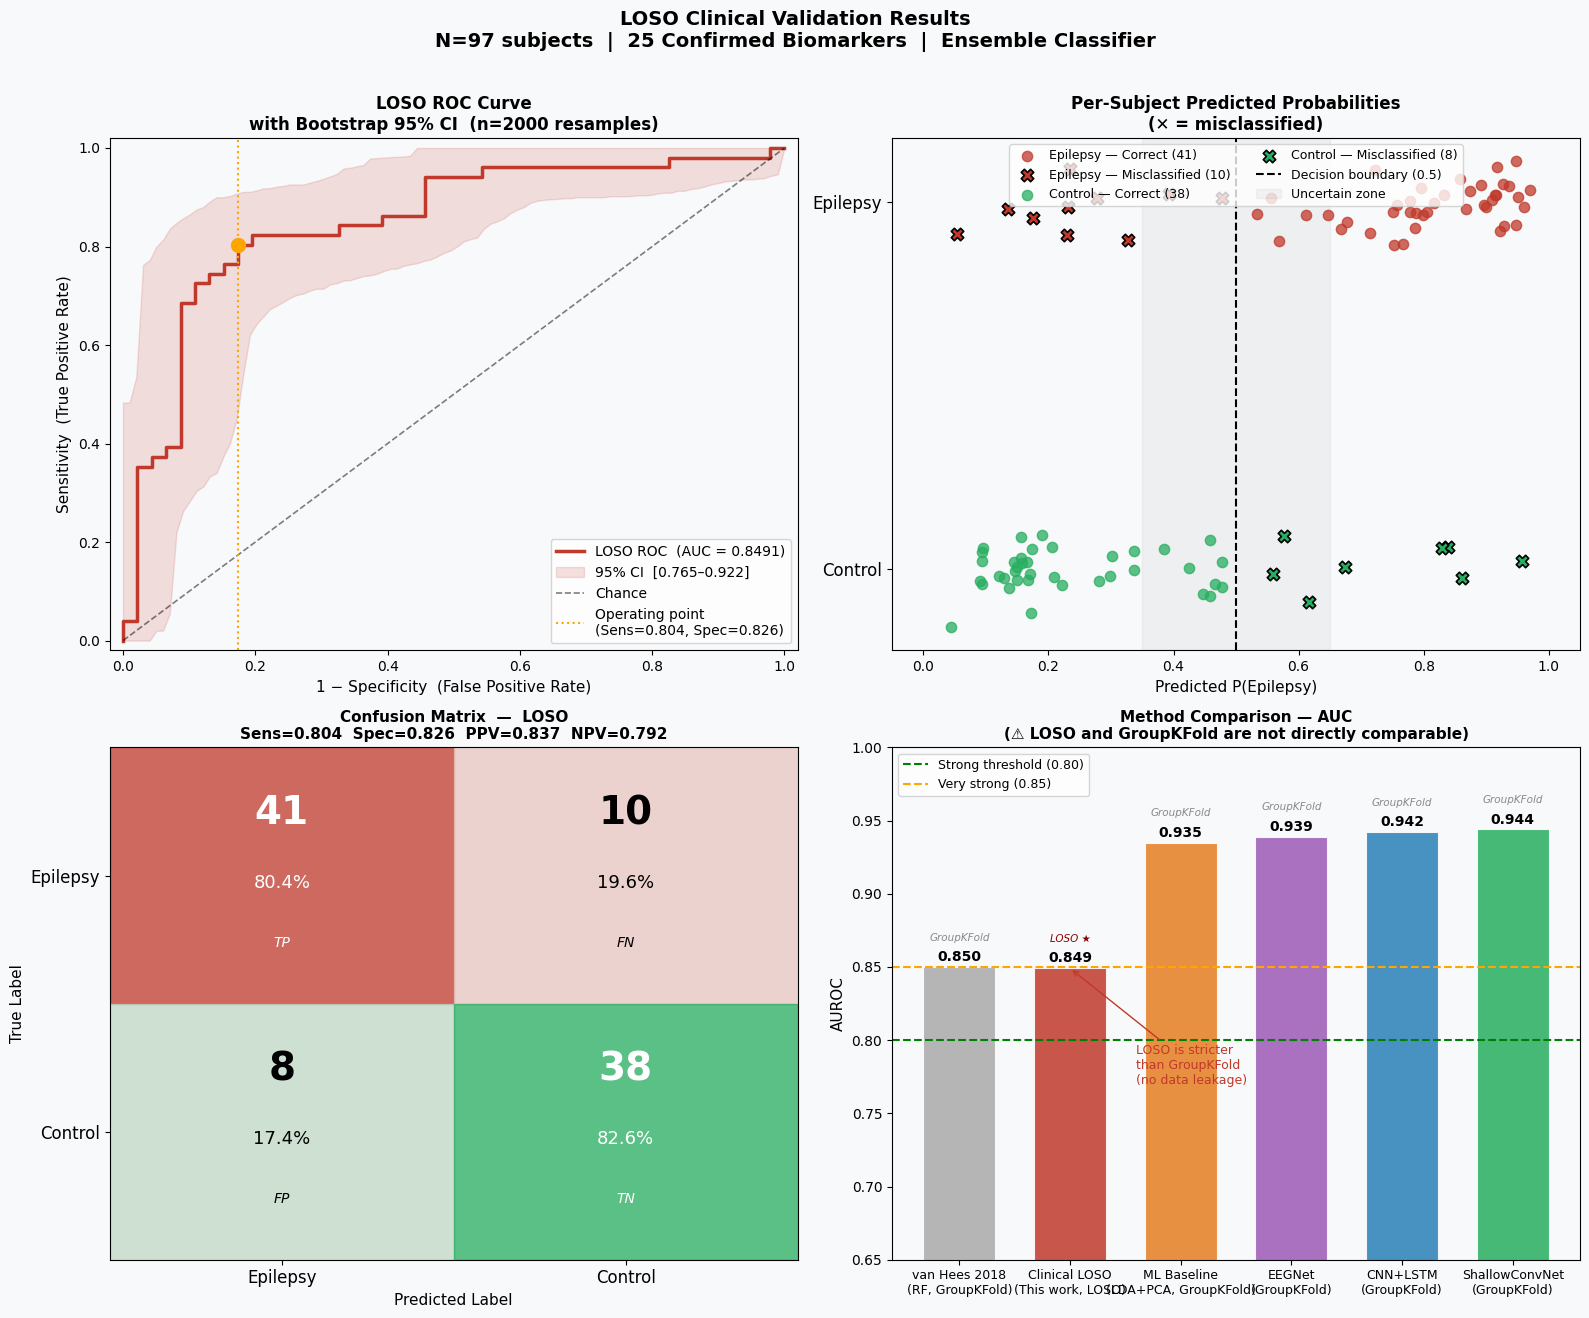

Saved: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers\07_loso_validation.png

Step 9 complete ✓


In [14]:
# ── Step 9: LOSO Visualisation ────────────────────────────────────────────────
# Plot 1: ROC curve with 95% CI band
# Plot 2: Per-subject probability plot (calibration + uncertainty)
# Plot 3: Confusion matrix (styled)
# Plot 4: Method comparison bar chart (honest — noting CV differences)

from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor(CLR['bg'])
axes = axes.flatten()

# ── Plot 1: ROC curve + bootstrap CI band ─────────────────────────────────────
ax = axes[0]
ax.set_facecolor(CLR['bg'])

# Bootstrap ROC curves for CI band
np.random.seed(SEED)
tprs, base_fpr = [], np.linspace(0, 1, 100)
for _ in range(2000):
    idx = np.random.randint(0, len(y_true_all), len(y_true_all))
    if len(np.unique(y_true_all[idx])) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_true_all[idx], y_prob_all[idx])
    tprs.append(np.interp(base_fpr, fpr_b, tpr_b))

tprs       = np.array(tprs)
mean_tpr   = tprs.mean(axis=0)
tpr_lo     = np.percentile(tprs, 2.5,  axis=0)
tpr_hi     = np.percentile(tprs, 97.5, axis=0)

# Main ROC
fpr_main, tpr_main, _ = roc_curve(y_true_all, y_prob_all)
ax.plot(fpr_main, tpr_main, color=CLR['epilepsy'], lw=2.5,
        label=f'LOSO ROC  (AUC = {auroc:.4f})')
ax.fill_between(base_fpr, tpr_lo, tpr_hi,
                color=CLR['epilepsy'], alpha=0.15,
                label=f'95% CI  [{ci_lo:.3f}–{ci_hi:.3f}]')
ax.plot([0,1],[0,1],'k--', lw=1.2, alpha=0.5, label='Chance')
ax.axvline(1 - specificity, color='orange', ls=':', lw=1.5,
           label=f'Operating point\n(Sens={sensitivity:.3f}, Spec={specificity:.3f})')
ax.scatter([1-specificity], [sensitivity],
           color='orange', s=100, zorder=5)

ax.set_xlabel('1 − Specificity  (False Positive Rate)', fontsize=11)
ax.set_ylabel('Sensitivity  (True Positive Rate)',       fontsize=11)
ax.set_title('LOSO ROC Curve\nwith Bootstrap 95% CI  (n=2000 resamples)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

# ── Plot 2: Per-subject probability strip ─────────────────────────────────────
ax = axes[1]
ax.set_facecolor(CLR['bg'])

epi_probs  = loso_df[loso_df['group']=='Epilepsy']['prob_epilepsy'].values
ctrl_probs = loso_df[loso_df['group']=='Control' ]['prob_epilepsy'].values
epi_correct  = loso_df[loso_df['group']=='Epilepsy']['correct'].values
ctrl_correct = loso_df[loso_df['group']=='Control' ]['correct'].values

np.random.seed(SEED)
for probs, correct, y_pos, label, color in [
    (epi_probs,  epi_correct,  1, 'Epilepsy', CLR['epilepsy']),
    (ctrl_probs, ctrl_correct, 0, 'Control',  CLR['control']),
]:
    jitter = np.random.normal(0, 0.06, len(probs))
    # Correct predictions
    mask_c = correct == 1
    ax.scatter(probs[mask_c],  np.full(mask_c.sum(),  y_pos) + jitter[mask_c],
               color=color, s=55, alpha=0.75, zorder=3,
               label=f'{label} — Correct ({mask_c.sum()})')
    # Misclassified
    mask_w = correct == 0
    ax.scatter(probs[mask_w], np.full(mask_w.sum(), y_pos) + jitter[mask_w],
               color=color, s=80, alpha=1.0, marker='X', edgecolors='black',
               linewidths=1.2, zorder=4,
               label=f'{label} — Misclassified ({mask_w.sum()})')

ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Decision boundary (0.5)')
ax.axvspan(0.35, 0.65, alpha=0.08, color='gray', label='Uncertain zone')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Control', 'Epilepsy'], fontsize=12)
ax.set_xlabel('Predicted P(Epilepsy)', fontsize=11)
ax.set_title('Per-Subject Predicted Probabilities\n(✕ = misclassified)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper center', ncol=2)
ax.set_xlim(-0.05, 1.05)

# ── Plot 3: Confusion matrix ───────────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor(CLR['bg'])

cm = np.array([[tp, fn], [fp, tn]])
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

labels = ['Epilepsy', 'Control']
colors_cm = [
    [CLR['epilepsy'], '#E8C5C0'],
    ['#C0D8C5',       CLR['control']],
]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                     color=colors_cm[i][j], alpha=0.75))
        count = cm[i, j]
        pct   = cm_pct[i, j]
        lbl   = ('TP' if i==0 and j==0 else 'FN' if i==0 and j==1
                 else 'FP' if i==1 and j==0 else 'TN')
        ax.text(j+0.5, 1.5-i+0.2, str(count),
                ha='center', fontsize=28, fontweight='bold',
                color='white' if i==j else 'black')
        ax.text(j+0.5, 1.5-i-0.05, f'{pct:.1f}%',
                ha='center', fontsize=13, color='white' if i==j else 'black')
        ax.text(j+0.5, 1.5-i-0.28, lbl,
                ha='center', fontsize=10, style='italic',
                color='white' if i==j else 'black')

ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(['Control', 'Epilepsy'], fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
ax.set_title(f'Confusion Matrix  —  LOSO\n'
             f'Sens={sensitivity:.3f}  Spec={specificity:.3f}  '
             f'PPV={ppv:.3f}  NPV={npv:.3f}',
             fontsize=11, fontweight='bold')

# ── Plot 4: Method comparison ─────────────────────────────────────────────────
ax = axes[3]
ax.set_facecolor(CLR['bg'])

methods = [
    ('van Hees 2018\n(RF, GroupKFold)',     0.850,  '#AAAAAA',  'GroupKFold'),
    ('Clinical LOSO\n(This work, LOSO)',    auroc,  CLR['epilepsy'], 'LOSO ★'),
    ('ML Baseline\n(LDA+PCA, GroupKFold)', 0.935,  '#E67E22',  'GroupKFold'),
    ('EEGNet\n(GroupKFold)',               0.939,  '#9B59B6',  'GroupKFold'),
    ('CNN+LSTM\n(GroupKFold)',             0.942,  '#2980B9',  'GroupKFold'),
    ('ShallowConvNet\n(GroupKFold)',       0.944,  '#27AE60',  'GroupKFold'),
]
x_pos  = np.arange(len(methods))
labels_, aucs, colors_, cv_types = zip(*methods)

bars = ax.bar(x_pos, aucs, color=colors_, alpha=0.85,
              edgecolor='white', linewidth=0.8, width=0.65)

# Value labels
for bar, auc_v, cv in zip(bars, aucs, cv_types):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{auc_v:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.018,
            cv, ha='center', fontsize=7.5,
            color='darkred' if cv == 'LOSO ★' else '#888888',
            style='italic')

ax.axhline(0.80, color='green',  ls='--', lw=1.5, label='Strong threshold (0.80)')
ax.axhline(0.85, color='orange', ls='--', lw=1.5, label='Very strong (0.85)')

# Annotation: LOSO is stricter
ax.annotate('LOSO is stricter\nthan GroupKFold\n(no data leakage)',
            xy=(1, auroc), xytext=(1.6, 0.77),
            arrowprops=dict(arrowstyle='->', color=CLR['epilepsy']),
            fontsize=9, color=CLR['epilepsy'])

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_, fontsize=9)
ax.set_ylabel('AUROC', fontsize=11)
ax.set_ylim(0.65, 1.0)
ax.set_title('Method Comparison — AUC\n'
             '(⚠ LOSO and GroupKFold are not directly comparable)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('LOSO Clinical Validation Results\n'
             'N=97 subjects  |  25 Confirmed Biomarkers  |  Ensemble Classifier',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

p_loso = os.path.join(PLOTS_DIR, '07_loso_validation.png')
plt.savefig(p_loso, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p_loso}")
print("\nStep 9 complete ✓")

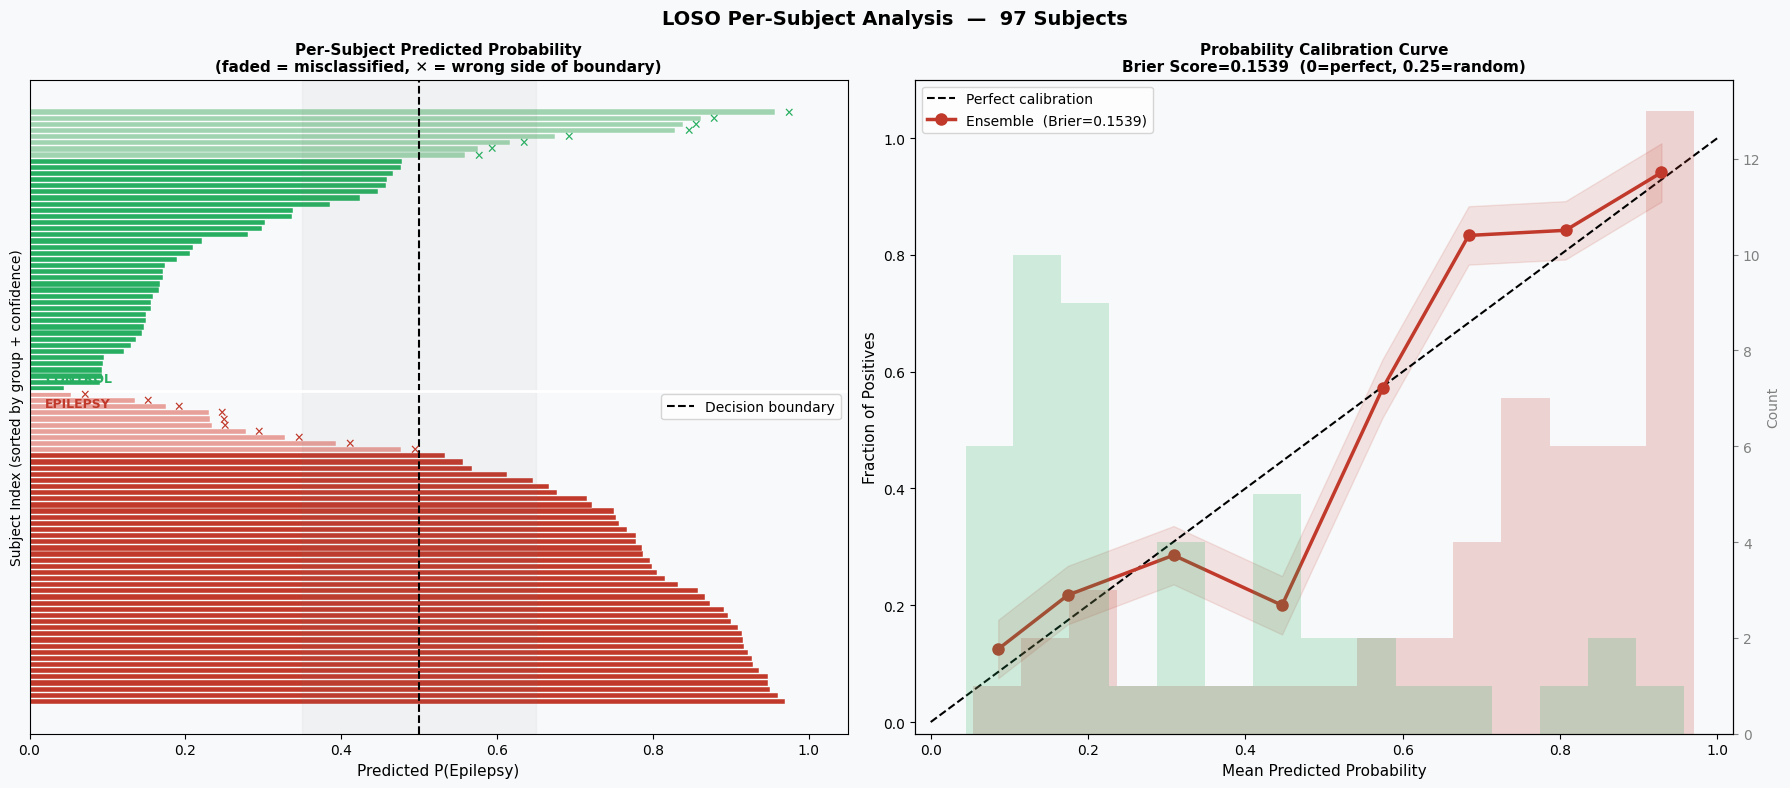

Saved: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers\08a_per_subject_probabilities.png


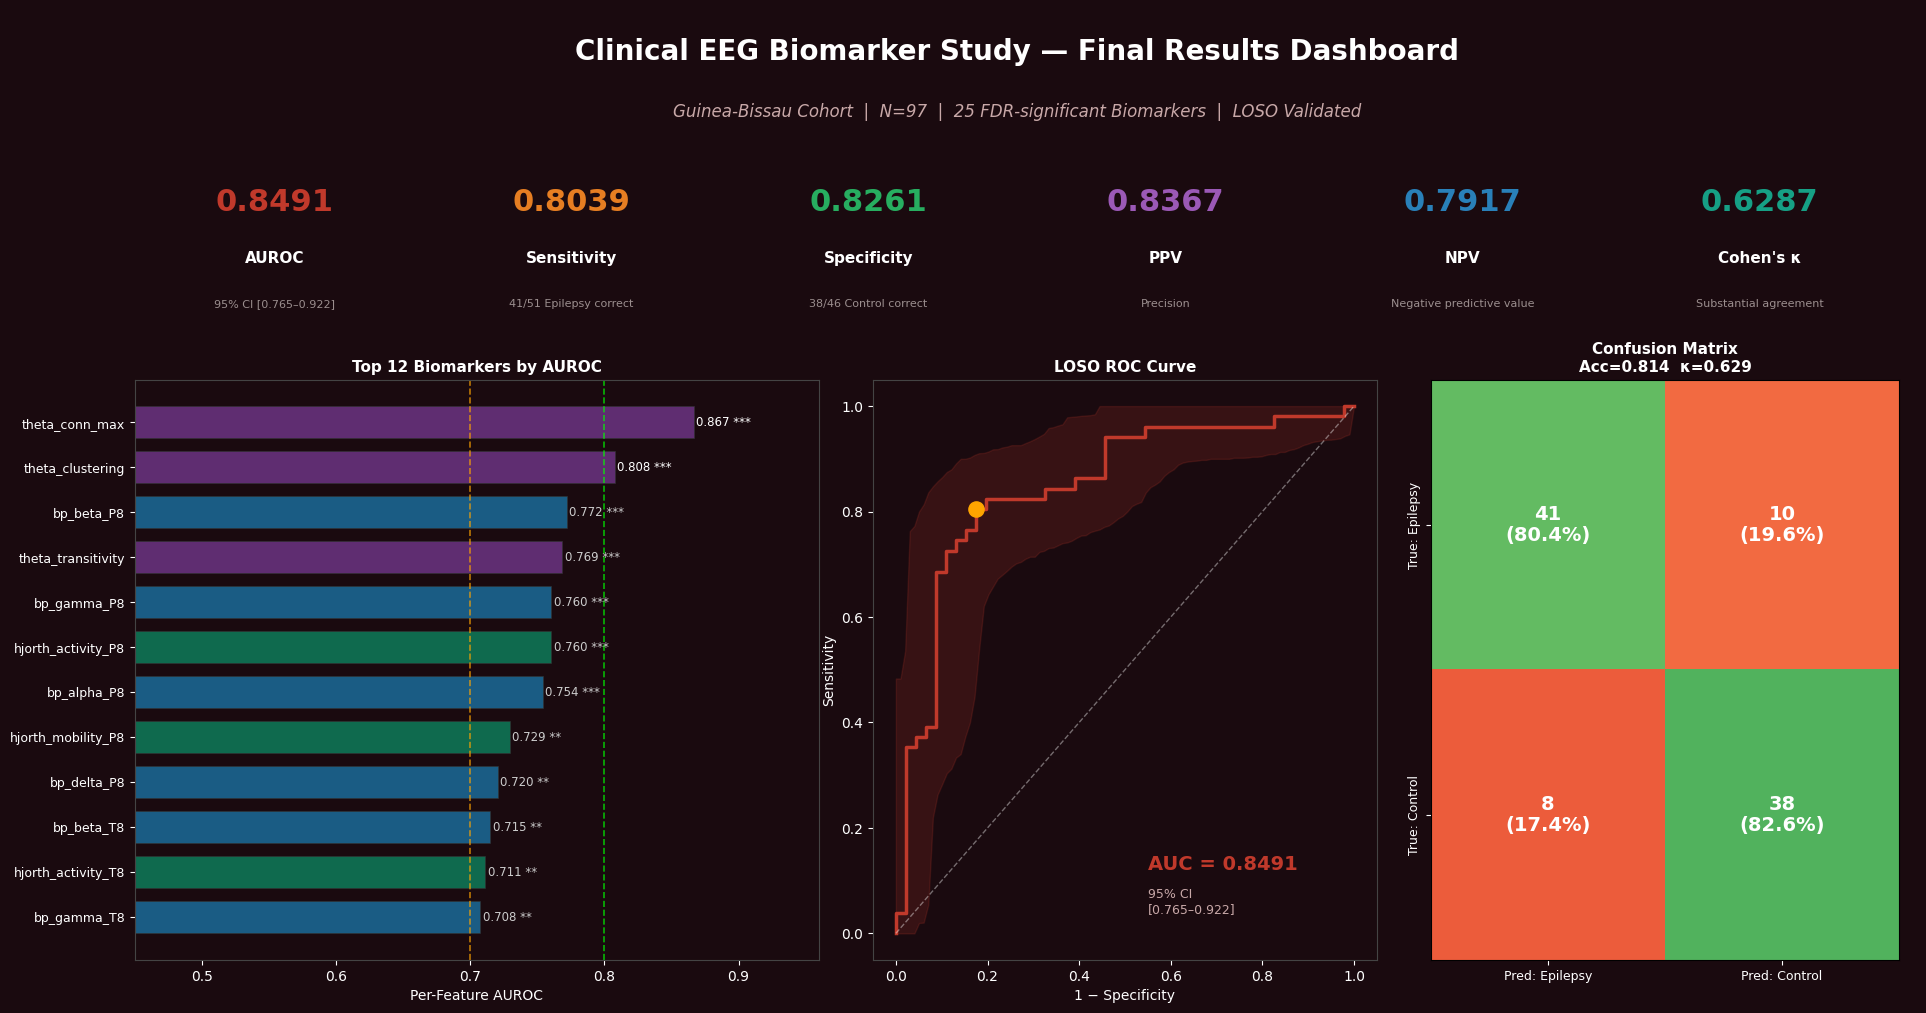

Saved: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers\08b_final_dashboard.png

Step 10 complete ✓

════════════════════════════════════════════════════════════
  ALL STEPS COMPLETE
  Plots saved to: C:\Users\DYPIU\Desktop\Epilepsy Classification\plots\clinical_biomarkers
════════════════════════════════════════════════════════════


In [15]:
# ── Step 10: Per-Subject Report Cards + Final Summary ─────────────────────────

# ── Plot 1: Per-subject probability heatmap sorted by true label + confidence ─
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(CLR['bg'])

# Sort: epilepsy first (by prob desc), then control (by prob asc)
epi_df  = loso_df[loso_df['group']=='Epilepsy'].sort_values('prob_epilepsy', ascending=False).reset_index(drop=True)
ctrl_df = loso_df[loso_df['group']=='Control' ].sort_values('prob_epilepsy', ascending=True ).reset_index(drop=True)
sorted_df = pd.concat([epi_df, ctrl_df]).reset_index(drop=True)

# Colour: correct=solid, wrong=lighter
bar_colors = []
for _, row in sorted_df.iterrows():
    if row['true_label'] == 1:
        bar_colors.append(CLR['epilepsy'] if row['correct'] else '#E8A09A')
    else:
        bar_colors.append(CLR['control']  if row['correct'] else '#A0D4B0')

ax = axes[0]
ax.set_facecolor(CLR['bg'])
bars = ax.barh(range(len(sorted_df)), sorted_df['prob_epilepsy'],
               color=bar_colors, height=0.85, edgecolor='white', linewidth=0.3)

ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Decision boundary')
ax.axvspan(0.35, 0.65, alpha=0.06, color='gray')
ax.axhline(len(epi_df) - 0.5, color='white', lw=2, ls='-')
ax.text(0.02, len(epi_df) + 1, 'CONTROL', fontsize=9,
        color=CLR['control'], fontweight='bold')
ax.text(0.02, len(epi_df) - 3, 'EPILEPSY', fontsize=9,
        color=CLR['epilepsy'], fontweight='bold')

# Mark misclassified
for i, (_, row) in enumerate(sorted_df.iterrows()):
    if not row['correct']:
        ax.text(row['prob_epilepsy'] + 0.01, i, '✕',
                va='center', fontsize=9,
                color=CLR['epilepsy'] if row['true_label']==1 else CLR['control'])

ax.set_xlabel('Predicted P(Epilepsy)', fontsize=11)
ax.set_ylabel('Subject Index (sorted by group + confidence)', fontsize=10)
ax.set_title('Per-Subject Predicted Probability\n'
             '(faded = misclassified, ✕ = wrong side of boundary)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_yticks([])

# ── Plot 2: Calibration curve ─────────────────────────────────────────────────
from sklearn.calibration import calibration_curve

ax2 = axes[1]
ax2.set_facecolor(CLR['bg'])

fraction_pos, mean_pred = calibration_curve(y_true_all, y_prob_all, n_bins=8)
ax2.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')
ax2.plot(mean_pred, fraction_pos, 'o-',
         color=CLR['epilepsy'], lw=2.5, ms=8,
         label=f'Ensemble  (Brier={brier:.4f})')

# Confidence band
ax2.fill_between(mean_pred,
                 fraction_pos - 0.05, fraction_pos + 0.05,
                 color=CLR['epilepsy'], alpha=0.12)

# Histogram of predicted probs
ax2b = ax2.twinx()
ax2b.hist(y_prob_all[y_true_all==1], bins=15, alpha=0.2,
          color=CLR['epilepsy'], label='Epilepsy probs')
ax2b.hist(y_prob_all[y_true_all==0], bins=15, alpha=0.2,
          color=CLR['control'],  label='Control probs')
ax2b.set_ylabel('Count', fontsize=10, color='gray')
ax2b.tick_params(colors='gray')

ax2.set_xlabel('Mean Predicted Probability', fontsize=11)
ax2.set_ylabel('Fraction of Positives',      fontsize=11)
ax2.set_title('Probability Calibration Curve\n'
              f'Brier Score={brier:.4f}  (0=perfect, 0.25=random)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.02, 1.10)

plt.suptitle('LOSO Per-Subject Analysis  —  97 Subjects',
             fontsize=14, fontweight='bold')
plt.tight_layout()
p8a = os.path.join(PLOTS_DIR, '08a_per_subject_probabilities.png')
plt.savefig(p8a, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p8a}")

# ── Plot 2: Final comprehensive summary dashboard ─────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#1A0A0F')

# ── Header ────────────────────────────────────────────────────────────────────
ax_hdr = fig.add_axes([0.0, 0.88, 1.0, 0.12])
ax_hdr.set_facecolor('#1A0A0F')
ax_hdr.axis('off')
ax_hdr.text(0.5, 0.65, 'Clinical EEG Biomarker Study — Final Results Dashboard',
            ha='center', va='center', fontsize=20, fontweight='bold',
            color='white', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.15,
            'Guinea-Bissau Cohort  |  N=97  |  25 FDR-significant Biomarkers  |  LOSO Validated',
            ha='center', va='center', fontsize=12, color='#C8A8A8',
            transform=ax_hdr.transAxes, style='italic')

# ── 6 metric cards ────────────────────────────────────────────────────────────
metrics_dash = [
    ('AUROC',        f'{auroc:.4f}',      f'95% CI [{ci_lo:.3f}–{ci_hi:.3f}]', CLR['epilepsy']),
    ('Sensitivity',  f'{sensitivity:.4f}', '41/51 Epilepsy correct',            '#E67E22'),
    ('Specificity',  f'{specificity:.4f}', '38/46 Control correct',             CLR['control']),
    ('PPV',          f'{ppv:.4f}',         'Precision',                         '#9B59B6'),
    ('NPV',          f'{npv:.4f}',         'Negative predictive value',         '#2980B9'),
    ("Cohen's κ",    f'{kappa:.4f}',       'Substantial agreement',             '#16A085'),
]
for i, (label, val, sub, color) in enumerate(metrics_dash):
    left = 0.01 + i * 0.165
    ax_c = fig.add_axes([left, 0.68, 0.155, 0.17])
    ax_c.set_facecolor('#2A1015')
    ax_c.spines[:].set_color(color)
    ax_c.spines[:].set_linewidth(2)
    ax_c.axis('off')
    ax_c.text(0.5, 0.75, val,   ha='center', va='center', fontsize=22,
              fontweight='bold', color=color,  transform=ax_c.transAxes)
    ax_c.text(0.5, 0.42, label, ha='center', va='center', fontsize=11,
              fontweight='bold', color='white', transform=ax_c.transAxes)
    ax_c.text(0.5, 0.15, sub,   ha='center', va='center', fontsize=8,
              color='#9B8E8E', transform=ax_c.transAxes)

# ── Top biomarkers bar (left) ─────────────────────────────────────────────────
ax_bio = fig.add_axes([0.01, 0.05, 0.38, 0.58])
ax_bio.set_facecolor('#1A0A0F')

top12     = stats_df.head(12)
tc_map    = {'Band Power':'#1A6B9A','Graph Theory':'#6C3483','Nonlinear':'#0E7C5A'}
bc2       = [tc_map[t] for t in top12['tier']]
bh        = ax_bio.barh(range(12), top12['auroc'],
                         color=bc2, alpha=0.85, height=0.72,
                         edgecolor='#333333', linewidth=0.5)
ax_bio.axvline(0.80, color='lime',  ls='--', lw=1.2, alpha=0.7)
ax_bio.axvline(0.70, color='orange',ls='--', lw=1.2, alpha=0.7)
for i, (bar, row) in enumerate(zip(bh, top12.itertuples())):
    ax_bio.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{row.auroc:.3f} {row.sig_label}',
                va='center', fontsize=8.5,
                color='white' if row.auroc >= 0.80 else '#CCCCCC')
ax_bio.set_yticks(range(12))
ax_bio.set_yticklabels(top12['feature'], fontsize=9, color='white')
ax_bio.invert_yaxis()
ax_bio.set_xlabel('Per-Feature AUROC', fontsize=10, color='white')
ax_bio.set_title('Top 12 Biomarkers by AUROC', fontsize=11,
                  fontweight='bold', color='white')
ax_bio.tick_params(colors='white')
ax_bio.set_facecolor('#1A0A0F')
for spine in ax_bio.spines.values():
    spine.set_color('#444444')
ax_bio.set_xlim(0.45, 0.96)

# ── ROC inset (middle) ────────────────────────────────────────────────────────
ax_roc = fig.add_axes([0.42, 0.05, 0.28, 0.58])
ax_roc.set_facecolor('#1A0A0F')
ax_roc.plot(fpr_main, tpr_main, color=CLR['epilepsy'], lw=2.5)
ax_roc.fill_between(base_fpr, tpr_lo, tpr_hi,
                     color=CLR['epilepsy'], alpha=0.18)
ax_roc.plot([0,1],[0,1],'w--', lw=1, alpha=0.4)
ax_roc.scatter([1-specificity],[sensitivity],
                color='orange', s=120, zorder=5)
ax_roc.text(0.55, 0.12, f'AUC = {auroc:.4f}',
             fontsize=14, fontweight='bold', color=CLR['epilepsy'])
ax_roc.text(0.55, 0.04, f'95% CI\n[{ci_lo:.3f}–{ci_hi:.3f}]',
             fontsize=9, color='#C8A8A8')
ax_roc.set_xlabel('1 − Specificity', fontsize=10, color='white')
ax_roc.set_ylabel('Sensitivity',      fontsize=10, color='white')
ax_roc.set_title('LOSO ROC Curve', fontsize=11, fontweight='bold', color='white')
ax_roc.tick_params(colors='white')
for spine in ax_roc.spines.values():
    spine.set_color('#444444')

# ── Confusion matrix inset (right) ───────────────────────────────────────────
ax_cm = fig.add_axes([0.73, 0.05, 0.26, 0.58])
ax_cm.set_facecolor('#1A0A0F')
cm_data  = np.array([[tp, fn], [fp, tn]])
cm_norm  = cm_data / cm_data.sum(axis=1, keepdims=True)
im = ax_cm.imshow(cm_norm, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, f'{cm_data[i,j]}\n({cm_norm[i,j]*100:.1f}%)',
                   ha='center', va='center', fontsize=14,
                   fontweight='bold', color='white')
ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
ax_cm.set_xticklabels(['Pred: Epilepsy','Pred: Control'],
                        fontsize=9, color='white')
ax_cm.set_yticklabels(['True: Epilepsy','True: Control'],
                        fontsize=9, color='white', rotation=90, va='center')
ax_cm.set_title(f'Confusion Matrix\nAcc={accuracy:.3f}  κ={kappa:.3f}',
                 fontsize=11, fontweight='bold', color='white')
ax_cm.tick_params(colors='white')

plt.suptitle('')
p8b = os.path.join(PLOTS_DIR, '08b_final_dashboard.png')
plt.savefig(p8b, dpi=150, bbox_inches='tight', facecolor='#1A0A0F')
plt.show()
print(f"Saved: {p8b}")
print("\nStep 10 complete ✓")
print("\n" + "═"*60)
print("  ALL STEPS COMPLETE")
print("  Plots saved to:", PLOTS_DIR)
print("═"*60)

In [5]:
# ── Paste this as a new cell and run it ──────────────────────────────────────
# Saves 3 dashboard panels to the IEEE folder.
# Run AFTER your LOSO cell (cells 9 and 10 in your notebook).
# Requires: y_true_all, y_prob_all, auroc, ci_lo, ci_hi,
#           sensitivity, specificity, ppv, npv, kappa, brier,
#           tp, fn, fp, tn, stats_df, SEED
# ─────────────────────────────────────────────────────────────────────────────

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve

# ── Settings ──────────────────────────────────────────────────────────────────
IEEE_DIR = r'D:\Final Year Internship\EEG Epilepsy Final\Epilepsy Classification\plots\ieee_figures'
os.makedirs(IEEE_DIR, exist_ok=True)

FS  = 20
DPI = 600

# Define colours here so this cell is fully self-contained
CLR = {
    'epilepsy':  '#C0392B',
    'control':   '#27AE60',
    'uncertain': '#F39C12',
    'bg':        '#F8F9FA',
}

tier_colors = {
    'Band Power':   '#2980B9',
    'Graph Theory': '#8E44AD',
    'Nonlinear':    '#16A085',
}

plt.rcParams.update({
    'font.size':        FS,
    'axes.titlesize':   FS,
    'axes.labelsize':   FS,
    'xtick.labelsize':  FS,
    'ytick.labelsize':  FS,
    'legend.fontsize':  FS - 2,
    'font.weight':      'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'lines.linewidth':  2.5,
    'figure.facecolor': CLR['bg'],
})

def save(fig, name, fc=None):
    path = os.path.join(IEEE_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches='tight',
                facecolor=fc if fc else fig.get_facecolor())
    plt.close(fig)
    kb = os.path.getsize(path) // 1024
    print(f'  Saved: {name}  ({kb} KB)')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Top-12 biomarker AUROC bar chart
# ══════════════════════════════════════════════════════════════════════════════
top12  = stats_df[stats_df['sig_fdr']].sort_values('auroc', ascending=False).head(12)
bclrs  = [tier_colors.get(t, '#888888') for t in top12['tier']]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor(CLR['bg'])
ax.set_facecolor(CLR['bg'])

bars = ax.barh(range(12), top12['auroc'], color=bclrs,
               alpha=0.88, height=0.7, edgecolor='white', linewidth=0.6)

ax.axvline(0.70, color='darkorange', ls='--', lw=2, label='AUROC = 0.70')
ax.axvline(0.80, color='green',      ls='--', lw=2, label='AUROC = 0.80')

for bar, row in zip(bars, top12.itertuples()):
    sig = ('***' if row.p_fdr < 0.001 else
           '**'  if row.p_fdr < 0.01  else '*')
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{row.auroc:.3f}  {sig}',
            va='center', fontsize=FS - 2, fontweight='bold',
            color='darkred' if row.auroc >= 0.80 else 'black')

ax.set_yticks(range(12))
ax.set_yticklabels(top12['feature'], fontsize=FS - 1, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Per-Feature AUROC  (subject-level, FDR-corrected)')
ax.set_title('Top-12 Validated EEG Biomarkers')
ax.set_xlim(0.45, 0.98)

legend_handles = [
    mpatches.Patch(color=c, label=t) for t, c in tier_colors.items()
] + [
    plt.Line2D([0],[0], color='darkorange', ls='--', lw=2, label='AUROC = 0.70'),
    plt.Line2D([0],[0], color='green',      ls='--', lw=2, label='AUROC = 0.80'),
]
ax.legend(handles=legend_handles, fontsize=FS - 4, loc='lower right')

plt.tight_layout()
save(fig, 'fig_dashboard_features.png')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — LOSO ROC curve with 95% bootstrap CI
# ══════════════════════════════════════════════════════════════════════════════

# Bootstrap CI
np.random.seed(SEED)
tprs, base_fpr = [], np.linspace(0, 1, 100)
for _ in range(2000):
    idx = np.random.randint(0, len(y_true_all), len(y_true_all))
    if len(np.unique(y_true_all[idx])) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_true_all[idx], y_prob_all[idx])
    tprs.append(np.interp(base_fpr, fpr_b, tpr_b))

tprs   = np.array(tprs)
tpr_lo = np.percentile(tprs, 2.5,  axis=0)
tpr_hi = np.percentile(tprs, 97.5, axis=0)
fpr_main, tpr_main, _ = roc_curve(y_true_all, y_prob_all)

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor(CLR['bg'])
ax.set_facecolor(CLR['bg'])

ax.plot(fpr_main, tpr_main, color=CLR['epilepsy'], lw=3,
        label=f'LOSO ROC  (AUC = {auroc:.4f})')
ax.fill_between(base_fpr, tpr_lo, tpr_hi,
                color=CLR['epilepsy'], alpha=0.15,
                label=f'95% CI  [{ci_lo:.3f} - {ci_hi:.3f}]')
ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Chance')
ax.scatter([1 - specificity], [sensitivity],
           color='darkorange', s=250, zorder=6,
           label=f'Op. point  (Sens={sensitivity:.3f}, Spec={specificity:.3f})')

ax.set_xlabel('1 - Specificity  (False Positive Rate)')
ax.set_ylabel('Sensitivity  (True Positive Rate)')
ax.set_title('LOSO ROC Curve\n(Bootstrap 95% CI,  n = 2000 resamples)')
ax.legend(fontsize=FS - 3, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
save(fig, 'fig_dashboard_roc.png')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Confusion matrix
# ══════════════════════════════════════════════════════════════════════════════
cm_arr    = np.array([[tp, fn], [fp, tn]])
cm_pct    = cm_arr / cm_arr.sum(axis=1, keepdims=True) * 100
colors_cm = [[CLR['epilepsy'], '#E8C5C0'],
             ['#C0D8C5',       CLR['control']]]
cell_lbl  = [['TP', 'FN'], ['FP', 'TN']]

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor(CLR['bg'])
ax.set_facecolor(CLR['bg'])

for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle(
            (j, 1 - i), 1, 1,
            color=colors_cm[i][j], alpha=0.85, zorder=1))

        # count (large)
        ax.text(j + 0.5, 1.5 - i + 0.18,
                str(cm_arr[i, j]),
                ha='center', va='center',
                fontsize=FS + 14, fontweight='bold', zorder=2,
                color='white' if i == j else '#222222')

        # percentage
        ax.text(j + 0.5, 1.5 - i - 0.05,
                f'{cm_pct[i, j]:.1f}%',
                ha='center', va='center',
                fontsize=FS, fontweight='bold', zorder=2,
                color='white' if i == j else '#333333')

        # TP / FN / FP / TN label
        ax.text(j + 0.5, 1.5 - i - 0.28,
                cell_lbl[i][j],
                ha='center', va='center',
                fontsize=FS - 2, style='italic', zorder=2,
                color='white' if i == j else '#555555')

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['Predicted\nEpilepsy', 'Predicted\nControl'],
                   fontsize=FS, fontweight='bold')
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['True\nControl', 'True\nEpilepsy'],
                   fontsize=FS, fontweight='bold')
ax.set_xlabel('Predicted Label', labelpad=12)
ax.set_ylabel('True Label',      labelpad=12)
ax.set_title(
    f'Confusion Matrix  -  LOSO  (N=97)\n'
    f'Sens={sensitivity:.3f}   Spec={specificity:.3f}   '
    f'PPV={ppv:.3f}   NPV={npv:.3f}   kappa={kappa:.3f}',
    pad=14)

plt.tight_layout()
save(fig, 'fig_dashboard_cm.png')

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print('Done.  3 figures saved to:')
print(f'  {IEEE_DIR}')

NameError: name 'stats_df' is not defined